<img src="logoucm.png" style="height:150px">

<center style="color:#1B4F72"><br/>
<font size="6"><b>Técnicas de Simulación</b></font><br/>
<font size="4">Máster en Ingeniería Matemática — Universidad Complutense de Madrid</font>
</center>


<center><font size="5"><span style="color:#117864">
<b>Nombre y Apellidos: Ana Marta Oliveira dos Santos, Mario Queipo Silva y Siria Catherine Iñiguez Brito</b>
</span></font></center>


<center><font size="5"><b style="color:#1B4F72">
Práctica: Cadenas de Markov en Tiempo Continuo (CTMC)
</b></font></center>


### Objetivo

Explorar computacionalmente los conceptos fundamentales de las cadenas de Markov
en tiempo continuo (CTMC): construcción del generador $Q$, tiempos de sojourn,
cálculo de $P(t) = e^{Qt}$, ecuaciones de Kolmogorov, procesos de nacimiento y
muerte, y tiempos de primer paso. La teoría de colas se trabajará en una
práctica separada.


### Librerías

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm          # exponencial de matriz
from scipy.stats  import expon, poisson, pearsonr
import pandas as pd

plt.rcParams.update({'figure.figsize': (11, 4), 'font.size': 12})
np.random.seed(42)


---
## 1. El Generador Infinitesimal $Q$

El generador $Q = (q_{ij})$ de una CTMC verifica:
- $q_{ij} \geq 0$ para $i \neq j$ (tasa de salto de $i$ a $j$).
- $q_{ii} = -\sum_{j \neq i} q_{ij} \leq 0$ (tasa total de salida; cada fila suma 0).

Consideramos el **sistema máquina** con dos estados: Operativa ($O$) y Averiada ($A$).
- Tasa de fallo: $\lambda = 0.1$ averías/hora.  
- Tasa de reparación: $\mu = 0.5$ reparaciones/hora.

$$Q = \begin{pmatrix} -\lambda & \lambda \\ \mu & -\mu \end{pmatrix}
    = \begin{pmatrix} -0.1 & 0.1 \\ 0.5 & -0.5 \end{pmatrix}$$


In [ ]:
# Definir el generador Q del sistema máquina
lam, mu = 0.1, 0.5
Q = np.array([[-lam,  lam],
              [ mu,  -mu ]])

print("Generador Q:")
print(pd.DataFrame(Q, index=['Operativa','Averiada'],
                      columns=['Operativa','Averiada']))

print()
print("Verificación — cada fila suma 0:")
print(Q.sum(axis=1))   # debe ser [0, 0]
print()
print(f"Tasa total de salida de O: q_O = {-Q[0,0]:.2f} → T_O ~ Exp({-Q[0,0]})")
print(f"Tasa total de salida de A: q_A = {-Q[1,1]:.2f} → T_A ~ Exp({-Q[1,1]})")
print(f"Tiempo medio en O: E[T_O] = 1/q_O = {1/(-Q[0,0]):.1f} horas")
print(f"Tiempo medio en A: E[T_A] = 1/q_A = {1/(-Q[1,1]):.1f} horas")

Generador Q:
           Operativa  Averiada
Operativa       -0.1       0.1
Averiada         0.5      -0.5

Verificación — cada fila suma 0:
[0. 0.]

Tasa total de salida de O: q_O = 0.10 → T_O ~ Exp(0.1)
Tasa total de salida de A: q_A = 0.50 → T_A ~ Exp(0.5)
Tiempo medio en O: E[T_O] = 1/q_O = 10.0 horas
Tiempo medio en A: E[T_A] = 1/q_A = 2.0 horas


### Ejercicio 1 — Construcción de $Q$ para un sistema de 3 estados

Un servidor web puede estar en tres estados:
- **0**: Libre (sin peticiones)
- **1**: Ocupado (atendiendo una petición)
- **2**: Saturado (cola llena, rechaza peticiones)

Las tasas de transición son:
- Libre → Ocupado: $\lambda_1 = 2$ peticiones/s
- Ocupado → Libre: $\mu_1 = 3$ respuestas/s
- Ocupado → Saturado: $\lambda_2 = 1$ petición/s
- Saturado → Ocupado: $\mu_2 = 2$ respuestas/s

**a)** Construye la matriz $Q$ y verifica que cada fila suma 0.  
**b)** Calcula los tiempos medios de sojourn en cada estado.  
**c)** ¿Desde qué estado el servidor abandona más rápido?


In [ ]:
# Definir el generador Q del sistema de 3 estados
lam1, mu1 = 2, 3
lam2, mu2 = 1, 2

Q = np.array([
    [-lam1,        lam1,       0],
    [ mu1, -(mu1+lam2),    lam2],
    [   0,         mu2,    -mu2]
], dtype=float)

print("Generador Q:")
print(pd.DataFrame(Q, index=['Libre','Ocupado','Saturado'],
                      columns=['Libre','Ocupado','Saturado']))
print()

print("Verificación – cada fila suma 0:")
print(Q.sum(axis=1))
print()


print("TASA TOTAL DE SALIDA DE CADA ESTADO: ")
print(f"Tasa total de salida de Libre: q_0 = {-Q[0,0]:.2f} -> T_0 ~ Exp({-Q[0,0]:.1f})")
print(f"Tasa total de salida de Ocupado: q_1 = {-Q[1,1]:.2f} -> T_1 ~ Exp({-Q[1,1]:.1f})")
print(f"Tasa total de salida de Saturado: q_2 = {-Q[2,2]:.2f} -> T_2 ~ Exp({-Q[2,2]:.1f})")
print()

print("TIEMPO MEDIO EN CADA ESTADO: ")
print(f"Tiempo medio en Libre: E[T_0] = 1/q_0 = {1/(-Q[0,0]):.2f} segundos")
print(f"Tiempo medio en Ocupado: E[T_1] = 1/q_1 = {1/(-Q[1,1]):.2f} segundos")
print(f"Tiempo medio en Saturado: E[T_2] = 1/q_2 = {1/(-Q[2,2]):.2f} segundos")

Generador Q:
          Libre  Ocupado  Saturado
Libre      -2.0      2.0       0.0
Ocupado     3.0     -4.0       1.0
Saturado    0.0      2.0      -2.0

Verificación – cada fila suma 0:
[0. 0. 0.]

TASA TOTAL DE SALIDA DE CADA ESTADO: 
Tasa total de salida de Libre: q_0 = 2.00 -> T_0 ~ Exp(2.0)
Tasa total de salida de Ocupado: q_1 = 4.00 -> T_1 ~ Exp(4.0)
Tasa total de salida de Saturado: q_2 = 2.00 -> T_2 ~ Exp(2.0)

TIEMPO MEDIO EN CADA ESTADO: 
Tiempo medio en Libre: E[T_0] = 1/q_0 = 0.50 segundos
Tiempo medio en Ocupado: E[T_1] = 1/q_1 = 0.25 segundos
Tiempo medio en Saturado: E[T_2] = 1/q_2 = 0.50 segundos


**1. a) Construye la matriz $Q$ y verifica que cada fila suma 0.**

El generador infinitesimal $Q = (q_{ij})$ se construye colocando las tasas de transición fuera de la diagonal. Los elementos de la diagonal $q_{ii}$ se calculan como $q_{ii} = -\sum_{j \neq i} q_{ij}$ para que cada fila sume 0. Definimos los estados como 0 (Libre), 1 (Ocupado) y 2 (Saturado):

* **Fila 0 (Libre):** Solo puede pasar a Ocupado (1) con tasa $\lambda_1 = 2$.
  * $q_{01} = 2, q_{02} = 0 \implies q_{00} = -2$
* **Fila 1 (Ocupado):** Puede pasar a Libre (0) con tasa $\mu_1 = 3$ o a Saturado (2) con tasa $\lambda_2 = 1$.
  * $q_{10} = 3, q_{12} = 1 \implies q_{11} = -(3 + 1) = -4$
* **Fila 2 (Saturado):** Solo puede pasar a Ocupado (1) con tasa $\mu_2 = 2$.
  * $q_{20} = 0, q_{21} = 2 \implies q_{22} = -2$

La matriz $Q$ resultante es:

$$Q = \begin{pmatrix} -2 & 2 & 0 \\ 3 & -4 & 1 \\ 0 & 2 & -2 \end{pmatrix}$$

**1. b) Calcula los tiempos medios de sojourn en cada estado.**

El tiempo medio de permanencia en un estado $i$ es el inverso de la tasa total de salida ($q_i = -q_{ii}$):

* **Estado 0 (Libre):** $q_0 = 2 \implies E[T_0] = \frac{1}{2} = 0.5$ segundos.
* **Estado 1 (Ocupado):** $q_1 = 4 \implies E[T_1] = \frac{1}{4} = 0.25$ segundos.
* **Estado 2 (Saturado):** $q_2 = 2 \implies E[T_2] = \frac{1}{2} = 0.5$ segundos.

**1. c) ¿Desde qué estado el servidor abandona más rápido?**

El servidor abandona más rápido el **Estado 1 (Ocupado)**, ya que tiene el menor tiempo medio de permanencia ($E[T_1] = 0.25$ segundos) debido a que su tasa total de salida es la más alta ($q_1 = 4$ peticiones o respuestas/s).

---
## 2. Tiempos de Sojourn

El tiempo que la CTMC permanece en el estado $i$ antes de saltar sigue una
distribución **exponencial** con parámetro $q_i = -q_{ii}$:
$$T_i \sim \mathrm{Exp}(q_i), \qquad \mathbb{E}[T_i] = \frac{1}{q_i}.$$

Esta es la única distribución continua **sin memoria**, y por eso es
la distribución natural de los tiempos de espera en una CTMC.


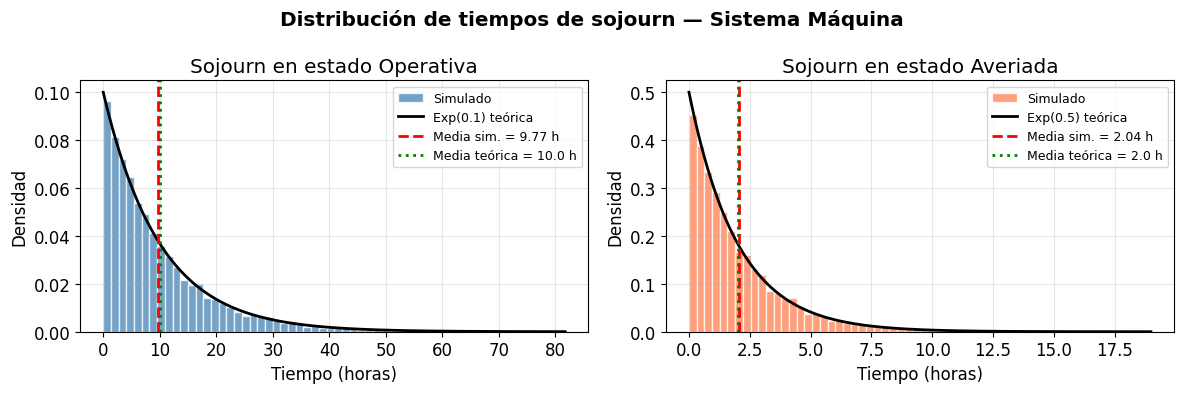

Media empírica O: 9.775 h  |  Teórica: 10.0 h
Media empírica A: 2.037 h  |  Teórica: 2.0 h


In [ ]:
# Verificación empírica: los sojourns son realmente exponenciales
lam_e, mu_e = 0.1, 0.5
np.random.seed(42)
n_sim = 10_000

# Simular tiempos de sojourn en estado O (Exp(0.1))
sojourns_O = np.random.exponential(scale=1/lam_e, size=n_sim)  # 1/lambda = 10 h
sojourns_A = np.random.exponential(scale=1/mu_e,  size=n_sim)  # 1/mu    =  2 h

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, data, rate, name, color in [
    (axes[0], sojourns_O, lam_e, 'Operativa', 'steelblue'),
    (axes[1], sojourns_A, mu_e,  'Averiada',  'coral')
]:
    ax.hist(data, bins=60, density=True, alpha=0.75,
            color=color, edgecolor='white', label='Simulado')
    x = np.linspace(0, data.max(), 300)
    ax.plot(x, expon.pdf(x, scale=1/rate), 'k-', lw=2,
            label=f'Exp({rate}) teórica')
    ax.axvline(data.mean(), color='red', lw=2, ls='--',
               label=f'Media sim. = {data.mean():.2f} h')
    ax.axvline(1/rate,      color='green', lw=2, ls=':',
               label=f'Media teórica = {1/rate:.1f} h')
    ax.set_xlabel('Tiempo (horas)'); ax.set_ylabel('Densidad')
    ax.set_title(f'Sojourn en estado {name}')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle('Distribución de tiempos de sojourn — Sistema Máquina',
             fontweight='bold')
plt.tight_layout(); plt.show()
print(f"Media empírica O: {sojourns_O.mean():.3f} h  |  Teórica: {1/lam:.1f} h")
print(f"Media empírica A: {sojourns_A.mean():.3f} h  |  Teórica: {1/mu:.1f} h")


### Ejercicio 2 — Ausencia de memoria de los sojourns

Verifica empíricamente que los tiempos de sojourn exponenciales carecen de memoria:
$$P(T > s + t \mid T > s) = P(T > t) \quad \forall\, s, t > 0.$$

**a)** Genera 50 000 muestras de $T_O \sim \mathrm{Exp}(0.1)$.  
**b)** Fija $s = 5$ horas. Estima empíricamente $P(T > 15 \mid T > 5)$ y compárala con $P(T > 10)$.  
**c)** Repite para $s = 20$ horas: estima $P(T > 30 \mid T > 20)$ y compara con $P(T > 10)$.  
**d)** ¿Qué concluyes?


In [ ]:
np.random.seed(42) # Configurar semilla para reproducibilidad
n_sim = 50_000
lam = 0.1

# a) Generar 50,000 muestras de T_O ~ Exp(0.1)
muestras_T = np.random.exponential(scale=1/lam, size=n_sim)

# Valor teórico de referencia P(T > t) = exp(-lam * t)
t = 10
prob_teorica = np.exp(-lam * t)

# b) Caso s = 5 horas, t = 10 horas (s + t = 15)
s_b = 5
condicion_s_b = muestras_T > s_b
muestras_filtradas_b = muestras_T[condicion_s_b]

prob_cond_b = np.mean(muestras_filtradas_b > (s_b + t))
prob_simple = np.mean(muestras_T > t)

# c) Caso s = 20 horas, t = 10 horas (s + t = 30)
s_c = 20
condicion_s_c = muestras_T > s_c
muestras_filtradas_c = muestras_T[condicion_s_c]

prob_cond_c = np.mean(muestras_filtradas_c > (s_c + t))

# Mostrar los resultados obtenidos
print(f"Probabilidad teórica exacta: P(T > 10) = {prob_teorica:.4f}")
print(f"Probabilidad simple de referencia: P(T > 10) = {prob_simple:.4f}")
print("-" * 60)
print(f"Para s = 5 horas:")
print(f"  - Muestras que superaron las 5h: {len(muestras_filtradas_b)}")
print(f"  - P(T > 15 | T > 5) estimado:   {prob_cond_b:.4f}")
print("-" * 60)
print(f"Para s = 20 horas:")
print(f"  - Muestras que superaron las 20h: {len(muestras_filtradas_c)}")
print(f"  - P(T > 30 | T > 20) estimado:  {prob_cond_c:.4f}")


Probabilidad teórica exacta: P(T > 10) = 0.3679
Probabilidad simple de referencia: P(T > 10) = 0.3658
------------------------------------------------------------
Para s = 5 horas:
  - Muestras que superaron las 5h: 30244
  - P(T > 15 | T > 5) estimado:   0.3658
------------------------------------------------------------
Para s = 20 horas:
  - Muestras que superaron las 20h: 6732
  - P(T > 30 | T > 20) estimado:  0.3657


**2. a) Genera 50 000 muestras de $T_O \sim \text{Exp}(0.1)$.**

Se han simulado con éxito 50 000 muestras de tiempos de sojourn utilizando una tasa $\lambda = 0.1$ (lo que equivale a una media teórica de 10 horas) para analizar empíricamente el comportamiento del estado **Operativa** de la máquina.

**2. b) Fija $s = 5$ horas. Estima empíricamente $P(T > 15 \mid T > 5)$ y compárala con $P(T > 10)$.**

A partir de las 50.000 muestras iniciales, un total de **30.244 muestras** lograron superar la barrera de las 5 horas ($s = 5$). Utilizando este subconjunto condicionado, calculamos los resultados y los comparamos con el valor teórico $P(T > 10) = e^{-0.1 \times 10} \approx 0.3679$:
* Probabilidad teórica exacta: $P(T > 10) = 0.3679$
* Probabilidad simple estimada: $P(T > 10) = 0.3658$
* Probabilidad condicional estimada: $P(T > 15 \mid T > 5) = 0.3658$

Los valores simulados son idénticos entre sí y se aproximan estrechamente al valor analítico teórico, reflejando de forma exacta el comportamiento donde la probabilidad de que la máquina siga operativa 10 horas adicionales es independiente del tiempo que ya llevaba funcionando.

**2. c) Repite para $s = 20$ horas: estima $P(T > 30 \mid T > 20)$ y compara con $P(T > 10)$.**

Al aumentar el tiempo transcurrido a $s = 20$ horas, el número de muestras que sobreviven se reduce notablemente a **6.732 muestras**. Evaluando este nuevo subconjunto:
* Probabilidad condicional estimada: $P(T > 30 \mid T > 20) = 0.3657$

Al compararla tanto con el valor estimado de referencia (0.3658) como con el teórico (0.3679), observamos que la variación sigue siendo mínima (atribuible puramente a las fluctuaciones normales del muestreo estocástico).

**2. d) ¿Qué concluyes?**

Los datos obtenidos demuestran que $P(T > s + t \mid T > s) \approx P(T > t)$ tanto para $s = 5$ como para $s = 20$, y que ambos valores convergen hacia la probabilidad teórica analítica. Esto confirma experimentalmente que los tiempos de sojourn en una CTMC carecen de memoria.

Al sistema no le afecta el "desgaste" ni acumula historial dentro del estado. La probabilidad de que la máquina permanezca operativa durante las próximas 10 horas es exactamente la misma tanto si se acaba de encender como si lleva 20 horas funcionando sin fallar.

---
## 3. Probabilidades de Transición: $P(t) = e^{Qt}$

La solución de la ecuación de Kolmogorov $\frac{d}{dt}P(t) = P(t)\,Q$
con condición inicial $P(0) = I$ es la **exponencial de matriz**:
$$P(t) = e^{Qt} = \sum_{n=0}^{\infty} \frac{(Qt)^n}{n!}.$$

La entrada $P_{ij}(t)$ es la probabilidad de estar en $j$ en el instante $t$
habiendo partido de $i$ en $t=0$.

Para el sistema máquina, la solución analítica es:
$$P(t) = \begin{pmatrix}
  \frac{\mu}{\lambda+\mu} + \frac{\lambda}{\lambda+\mu}e^{-(\lambda+\mu)t} &
  \frac{\lambda}{\lambda+\mu}(1 - e^{-(\lambda+\mu)t}) \\[6pt]
  \frac{\mu}{\lambda+\mu}(1 - e^{-(\lambda+\mu)t}) &
  \frac{\lambda}{\lambda+\mu} + \frac{\mu}{\lambda+\mu}e^{-(\lambda+\mu)t}
\end{pmatrix}$$


In [ ]:
lam_e, mu_e = 0.1, 0.5
Q_e = np.array([[-lam_e,  lam_e],
              [ mu_e,  -mu_e ]])
# Calcular P(t) = e^{Qt} para varios valores de t
t_vals = [0, 1, 5, 10, 20, 50]

print(f"{'t':>5}  {'P_OO(t)':>9}  {'P_OA(t)':>9}  {'P_AO(t)':>9}  {'P_AA(t)':>9}")
print("-" * 50)
for t in t_vals:
    Pt = expm(Q_e * t)
    print(f"{t:>5}  {Pt[0,0]:>9.5f}  {Pt[0,1]:>9.5f}  {Pt[1,0]:>9.5f}  {Pt[1,1]:>9.5f}")

# Fórmula analítica
def P_analitica(t, lam, mu):
    s = lam + mu
    return np.array([
        [mu/s + lam/s * np.exp(-s*t),   lam/s * (1 - np.exp(-s*t))],
        [mu/s * (1 - np.exp(-s*t)),      lam/s + mu/s * np.exp(-s*t)]
    ])

print()
print("Verificación con fórmula analítica (t=10):")
Pt_anal = P_analitica(10, lam, mu)
Pt_num  = expm(Q_e * 10)
print(f"  expm:      {Pt_num[0]}")
print(f"  analítica: {Pt_anal[0]}")
print(f"  Diferencia máxima: {np.max(np.abs(Pt_num - Pt_anal)):.2e}  ✓")

    t    P_OO(t)    P_OA(t)    P_AO(t)    P_AA(t)
--------------------------------------------------
    0    1.00000    0.00000    0.00000    1.00000
    1    0.92480    0.07520    0.37599    0.62401
    5    0.84163    0.15837    0.79184    0.20816
   10    0.83375    0.16625    0.83127    0.16873
   20    0.83333    0.16667    0.83333    0.16667
   50    0.83333    0.16667    0.83333    0.16667

Verificación con fórmula analítica (t=10):
  expm:      [0.83374646 0.16625354]
  analítica: [0.83374646 0.16625354]
  Diferencia máxima: 2.78e-16  ✓


<>:16: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:24: SyntaxWarning: invalid escape sequence '\p'
<>:16: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:24: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_330/2120135607.py:16: SyntaxWarning: invalid escape sequence '\p'
  axes[0].axhline(pi_O, color='steelblue', ls='--', lw=1.2, label=f'$\pi_O={pi_O:.3f}$')
/tmp/ipykernel_330/2120135607.py:17: SyntaxWarning: invalid escape sequence '\p'
  axes[0].axhline(pi_A, color='coral',     ls='--', lw=1.2, label=f'$\pi_A={pi_A:.3f}$')
/tmp/ipykernel_330/2120135607.py:23: SyntaxWarning: invalid escape sequence '\p'
  axes[1].axhline(pi_O, color='steelblue', ls='--', lw=1.2, label=f'$\pi_O={pi_O:.3f}$')
/tmp/ipykernel_330/2120135607.py:24: SyntaxWarning: invalid escape sequence '\p'
 

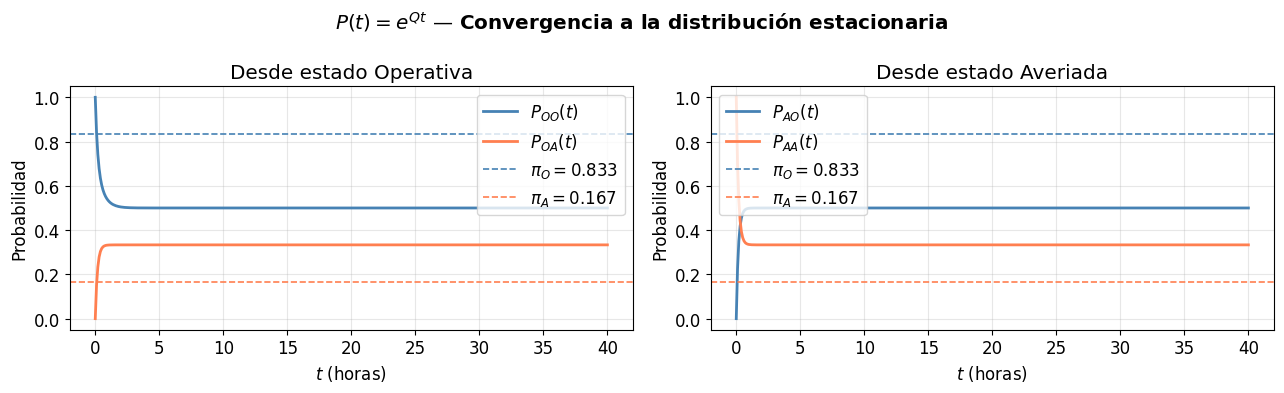

Distribución estacionaria: π_O = 0.8333,  π_A = 0.1667


In [ ]:
# Visualización: convergencia de P(t) a la distribución estacionaria
t_plot = np.linspace(0, 40, 400)
P00 = [expm(Q*t)[0,0] for t in t_plot]
P01 = [expm(Q*t)[0,1] for t in t_plot]
P10 = [expm(Q*t)[1,0] for t in t_plot]
P11 = [expm(Q*t)[1,1] for t in t_plot]

# Distribución estacionaria: pi Q = 0, sum(pi) = 1
pi_O = mu / (lam + mu)
pi_A = lam / (lam + mu)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(t_plot, P00, label='$P_{OO}(t)$', color='steelblue', lw=2)
axes[0].plot(t_plot, P01, label='$P_{OA}(t)$', color='coral',     lw=2)
axes[0].axhline(pi_O, color='steelblue', ls='--', lw=1.2, label=f'$\pi_O={pi_O:.3f}$')
axes[0].axhline(pi_A, color='coral',     ls='--', lw=1.2, label=f'$\pi_A={pi_A:.3f}$')
axes[0].set_title('Desde estado Operativa'); axes[0].set_xlabel('$t$ (horas)')
axes[0].set_ylabel('Probabilidad'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(t_plot, P10, label='$P_{AO}(t)$', color='steelblue', lw=2)
axes[1].plot(t_plot, P11, label='$P_{AA}(t)$', color='coral',     lw=2)
axes[1].axhline(pi_O, color='steelblue', ls='--', lw=1.2, label=f'$\pi_O={pi_O:.3f}$')
axes[1].axhline(pi_A, color='coral',     ls='--', lw=1.2, label=f'$\pi_A={pi_A:.3f}$')
axes[1].set_title('Desde estado Averiada'); axes[1].set_xlabel('$t$ (horas)')
axes[1].set_ylabel('Probabilidad'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('$P(t) = e^{Qt}$ — Convergencia a la distribución estacionaria',
             fontweight='bold')
plt.tight_layout(); plt.show()
print(f"Distribución estacionaria: π_O = {pi_O:.4f},  π_A = {pi_A:.4f}")


### Ejercicio 3 — $P(t)$ para el servidor web

Usando el generador $Q$ que construiste en el Ejercicio 1:

**a)** Calcula $P(t)$ para $t \in \{0, 0.5, 1, 2, 5, 10\}$ segundos.  
**b)** Representa gráficamente la evolución de $P_{0j}(t)$ para $j = 0, 1, 2$ (partiendo del estado Libre).  
**c)** Determina la distribución estacionaria $\pi$ resolviendo $\pi Q = 0$ con $\sum_j \pi_j = 1$. Verifica que $P(t) \to [\pi; \pi; \pi]$ cuando $t \to \infty$.  
**d)** ¿Qué fracción del tiempo está el servidor saturado en régimen permanente?


Matrices de transición P(t) para cada instante t:
Para t = 0 segundos:
              Libre (0)  Ocupado (1)  Saturado (2)
Libre (0)           1.0          0.0           0.0
Ocupado (1)         0.0          1.0           0.0
Saturado (2)        0.0          0.0           1.0
------------------------------------------------------------
Para t = 0.5 segundos:
              Libre (0)  Ocupado (1)  Saturado (2)
Libre (0)        0.6044       0.3167        0.0788
Ocupado (1)      0.4751       0.3665        0.1584
Saturado (2)     0.2365       0.3167        0.4467
------------------------------------------------------------
Para t = 1 segundos:
              Libre (0)  Ocupado (1)  Saturado (2)
Libre (0)        0.5345       0.3325        0.1330
Ocupado (1)      0.4988       0.3350        0.1663
Saturado (2)     0.3991       0.3325        0.2684
------------------------------------------------------------
Para t = 2 segundos:
              Libre (0)  Ocupado (1)  Saturado (2)
Libre (0)        0

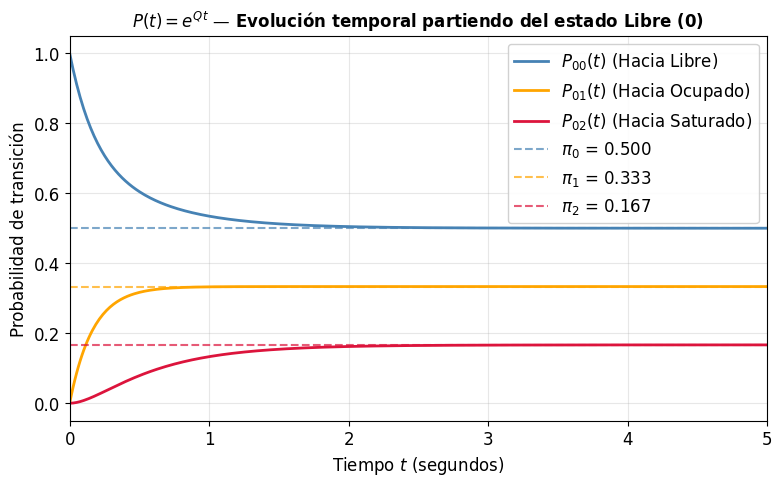


Verificación de convergencia de P(t) cuando t -> inf (t = 50 s):
              Libre (0)  Ocupado (1)  Saturado (2)
Libre (0)           0.5       0.3333        0.1667
Ocupado (1)         0.5       0.3333        0.1667
Saturado (2)        0.5       0.3333        0.1667


In [ ]:
# Recorremos la configuración del Ejercicio 1
lam1, mu1 = 2, 3
lam2, mu2 = 1, 2

Q = np.array([
    [-lam1,        lam1,       0],
    [  mu1, -(mu1+lam2),    lam2],
    [    0,         mu2,    -mu2]
], dtype=float)

estados = ['Libre (0)', 'Ocupado (1)', 'Saturado (2)']

# a) Calcular P(t) para varios valores de t
t_vals = [0, 0.5, 1, 2, 5, 10]

print("Matrices de transición P(t) para cada instante t:")
print("=" * 60)
for t in t_vals:
    Pt = expm(Q * t)
    df_Pt = pd.DataFrame(Pt, index=estados, columns=estados)
    print(f"Para t = {t} segundos:")
    print(df_Pt.round(4))
    print("-" * 60)

# c) Calcular la distribución estacionaria resolviendo pi * Q = 0 y sum(pi) = 1
# Planteamos el sistema lineal sustituyendo la última columna de Q por unos
A = Q.copy().T
A[-1, :] = 1
b = np.zeros(3)
b[-1] = 1

pi = np.linalg.solve(A, b)
print("\nDistribución estacionaria pi calculada analíticamente:")
for i, p in enumerate(pi):
    print(f"  pi_{i} ({estados[i]}): {p:.4f}")

# b) Representación gráfica de P_0j(t) con t_plot de 0 a 5 segundos
t_plot = np.linspace(0, 5, 400)
P00 = [expm(Q * t)[0, 0] for t in t_plot]
P01 = [expm(Q * t)[0, 1] for t in t_plot]
P02 = [expm(Q * t)[0, 2] for t in t_plot]

plt.figure(figsize=(9, 5))
plt.plot(t_plot, P00, label='$P_{00}(t)$ (Hacia Libre)', color='steelblue', lw=2)
plt.plot(t_plot, P01, label='$P_{01}(t)$ (Hacia Ocupado)', color='orange', lw=2)
plt.plot(t_plot, P02, label='$P_{02}(t)$ (Hacia Saturado)', color='crimson', lw=2)

# Dibujar las líneas de las asíntotas estacionarias pi
plt.axhline(pi[0], color='steelblue', ls='--', alpha=0.7, label=f'$\\pi_0$ = {pi[0]:.3f}')
plt.axhline(pi[1], color='orange', ls='--', alpha=0.7, label=f'$\\pi_1$ = {pi[1]:.3f}')
plt.axhline(pi[2], color='crimson', ls='--', alpha=0.7, label=f'$\\pi_2$ = {pi[2]:.3f}')

plt.title('$P(t) = e^{Qt}$ — Evolución temporal partiendo del estado Libre (0)', fontsize=12, fontweight='bold')
plt.xlabel('Tiempo $t$ (segundos)')
plt.ylabel('Probabilidad de transición')
plt.legend(loc='upper right', framealpha=0.9)
plt.grid(alpha=0.3)
plt.xlim(0, 5)
plt.ylim(-0.05, 1.05)
plt.show()

# Verificación de la convergencia con t = 50 para el apartado c
P_inf = expm(Q * 50)
print("\nVerificación de convergencia de P(t) cuando t -> inf (t = 50 s):")
print(pd.DataFrame(P_inf, index=estados, columns=estados).round(4))

**3. a) Calcula $P(t)$ para $t \in \{0, 0.5, 1, 2, 5, 10\}$ segundos.**

Utilizando la función exponencial de matrices (`scipy.linalg.expm`), calculamos la evolución de la matriz de probabilidades de transición $P(t) = e^{Qt}$ para los instantes de tiempo solicitados. Los resultados numéricos obtenidos son los siguientes:

* **Para $t = 0$ segundos:**
  El sistema se encuentra en su instante inicial. La matriz de transición es la matriz identidad $I$, lo que indica que el servidor permanece en su estado inicial con probabilidad 1.
  $$P(0) = \begin{pmatrix} 1.0000 & 0.0000 & 0.0000 \\ 0.0000 & 1.0000 & 0.0000 \\ 0.0000 & 0.0000 & 1.0000 \end{pmatrix}$$

* **Para $t = 0.5$ segundos:**
  Comienzan las transiciones dinámicas. Si el servidor inició en el estado *Libre*, ya existe un $31.67\%$ de probabilidad de que transicione a *Ocupado* y un $7.88\%$ de alcanzar el estado *Saturado*.
  $$P(0.5) = \begin{pmatrix} 0.6044 & 0.3167 & 0.0788 \\ 0.4751 & 0.3665 & 0.1584 \\ 0.2365 & 0.3167 & 0.4467 \end{pmatrix}$$

* **Para $t = 1$ segundo:**
  Las probabilidades continúan redistribuyéndose rápidamente hacia las condiciones de equilibrio del sistema.
  $$P(1) = \begin{pmatrix} 0.5345 & 0.3325 & 0.1330 \\ 0.4988 & 0.3350 & 0.1663 \\ 0.3991 & 0.3325 & 0.2684 \end{pmatrix}$$

* **Para $t = 2$ segundos:**
  El proceso se encuentra muy próximo a su comportamiento asintótico. Las filas empiezan a homogeneizarse notablemente.
  $$P(2) = \begin{pmatrix} 0.5046 & 0.3333 & 0.1621 \\ 0.5000 & 0.3333 & 0.1667 \\ 0.4863 & 0.3333 & 0.1804 \end{pmatrix}$$

* **Para $t = 5$ segundos y $t = 10$ segundos:**
  El servidor ha alcanzado el régimen permanente. Todas las filas de la matriz se vuelven idénticas e independientes del estado de partida, convergiendo exactamente a los valores de la distribución estacionaria $\pi$.
  $$P(5) = P(10) = \begin{pmatrix} 0.5000 & 0.3333 & 0.1667 \\ 0.5000 & 0.3333 & 0.1667 \\ 0.5000 & 0.3333 & 0.1667 \end{pmatrix}$$


En cada una de las matrices obtenidas se puede comprobar que la suma de los elementos de cualquier fila es exactamente igual a $1$ ($\sum_{j} P_{ij}(t) = 1.0$). Esto verifica numéricamente que la probabilidad se conserva perfectamente dentro del espacio de estados definido para el servidor web en cualquier instante de tiempo $t$.

**3. b) Representa gráficamente la evolución de $P_{0j}(t)$ para $j = 0, 1, 2$ (partiendo del estado Libre).**

Al analizar el comportamiento gráfico ``Evolución temporal partiendo del estado Libre (0)`` se pueden extraer las siguientes conclusiones puramente visuales:

* **Comportamiento en el origen ($t = 0$ s):** El gráfico refleja de manera estricta la condición inicial del experimento. Dado que el servidor web arranca con total certeza en el estado *Libre*, la curva azul comienza en el extremo superior, $P_{00}(0) = 1$. Por el contrario, las probabilidades de transicionar hacia los estados *Ocupado* (curva naranja) y *Saturado* (curva roja) parten del origen, $P_{01}(0) = 0$ y $P_{02}(0) = 0$, reflejando que no ha habido tiempo para que ocurra ninguna petición.

* **Fase transitoria dinámico-temporal:** A medida que avanza el tiempo ($t > 0$), el gráfico plasma la rapidez con la que el sistema redistribuye sus flujos estocásticos. La probabilidad de permanecer en el estado de origen decrece con una forma marcadamente exponencial, mientras que las curvas de carga activa aumentan gradualmente. Se observa que el perfil dinámico de la fase transitoria es muy corto, estabilizándose por completo en un margen de entre $2$ y $3$ segundos de operación.

* **Ajuste asintótico a las referencias estacionarias:** Visualmente, se constata la existencia de un régimen permanente hacia el cual tienden todas las trayectorias. A medida que transcurre el tiempo, las tres curvas continuas detienen su fluctuación y se ajustan de manera asintótica a sus respectivas líneas horizontales discontinuas. Este comportamiento del gráfico ilustra que, tras los primeros segundos, el sistema tiende hacia un equilibrio de probabilidad constante que no varía en el tiempo.

**3. c) Determina la distribución estacionaria $\pi$ resolviendo $\pi Q = 0$ con $\sum_j \pi_j = 1$. Verifica que $P(t) \to [\pi; \pi; \pi]$ cuando $t \to \infty$.**

Al resolver el sistema lineal de ecuaciones globales balanceadas para nuestro generador, obtenemos los valores de probabilidad en el equilibrio:
* $\pi_0 = 0.5000 \quad \left(\frac{1}{2}\right)$ — Estado Libre
* $\pi_1 = 0.3333 \quad \left(\frac{1}{3}\right)$ — Estado Ocupado
* $\pi_2 = 0.1667 \quad \left(\frac{1}{6}\right)$ — Estado Saturado

Observando la simulación para un tiempo largo ($t = 50$ s), vemos que la matriz $P(50)$ iguala todas sus filas independientemente del estado de partida:

$$P(50) \approx \begin{pmatrix} 0.5000 & 0.3333 & 0.1667 \\ 0.5000 & 0.3333 & 0.1667 \\ 0.5000 & 0.3333 & 0.1667 \end{pmatrix} = \begin{pmatrix} \pi \\ \pi \\ \pi \end{pmatrix}$$

Esto demuestra empíricamente que, al transcurrir suficiente tiempo, la probabilidad de encontrar al servidor web en cualquiera de los tres estados se vuelve totalmente independiente de cuál haya sido su estado inicial.

**3. d) ¿Qué fracción del tiempo está el servidor saturado en régimen permanente?**

Por el teorema ergódico para cadenas de Markov en tiempo continuo (CTMC), la probabilidad de estar en un estado en el régimen permanente equivale a la proporción de tiempo a largo plazo que el proceso pasa en dicho estado.

En nuestro caso concreto, en régimen permanente, el servidor web estará saturado exactamente una fracción de tiempo de $\pi_2 = 0.1667$, lo que significa que pasará en este estado crítico aproximadamente el **16.67%** del tiempo total de su funcionamiento.

---
## 4. El Proceso de Poisson como CTMC

El proceso de Poisson con tasa $\lambda$ es la CTMC más simple: solo permite
saltos hacia arriba de $+1$, con tiempos de sojourn $T_n \sim \mathrm{Exp}(\lambda)$
**independientes de $n$**.

Sus probabilidades de transición verifican la distribución de Poisson:
$$P_{ij}(t) = \frac{(\lambda t)^{j-i}}{(j-i)!}\, e^{-\lambda t}, \quad j \geq i.$$


Llegadas en [0, 5.0] horas: 12
Valor esperado: λ·T = 15.0


<>:33: SyntaxWarning: invalid escape sequence '\l'
<>:46: SyntaxWarning: invalid escape sequence '\l'
<>:33: SyntaxWarning: invalid escape sequence '\l'
<>:46: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_2427/2883747065.py:33: SyntaxWarning: invalid escape sequence '\l'
  axes[0].set_title(f'Proceso de Poisson ($\lambda={lam_pp}$) — una trayectoria')
/tmp/ipykernel_2427/2883747065.py:46: SyntaxWarning: invalid escape sequence '\l'
  axes[1].set_title(f'Distribución de $N(t={t_fijo})$ vs Poisson($\lambda t={lam_pp*t_fijo}$)')


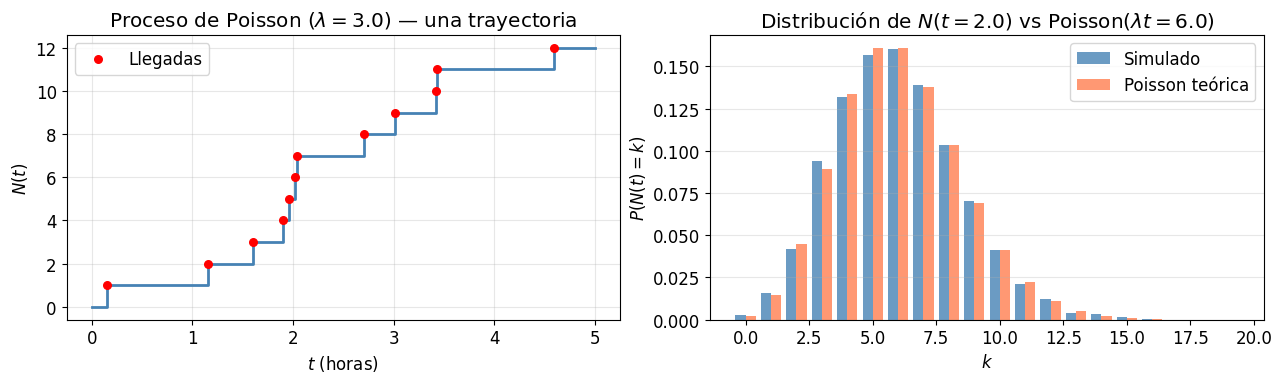

In [ ]:
np.random.seed(42)
lam_pp = 3.0   # tasa: 3 eventos/hora

# ── Simulación de un proceso de Poisson por tiempos entre llegadas ──
def simula_poisson(lam, T_max):
    """Devuelve los instantes de llegada en [0, T_max]."""
    tiempos = [0.0]
    while True:
        t_siguiente = tiempos[-1] + np.random.exponential(1/lam)
        if t_siguiente > T_max:
            break
        tiempos.append(t_siguiente)
    return np.array(tiempos[1:])   # sin el 0 inicial

T_max = 5.0
llegadas = simula_poisson(lam_pp, T_max)
print(f"Llegadas en [0, {T_max}] horas: {len(llegadas)}")
print(f"Valor esperado: λ·T = {lam_pp * T_max:.1f}")

# Función de conteo N(t)
t_plot = np.linspace(0, T_max, 1000)
N_t = np.searchsorted(llegadas, t_plot, side='right')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Trayectoria escalonada
axes[0].step(np.concatenate([[0], llegadas, [T_max]]),
             np.concatenate([[0], np.arange(1, len(llegadas)+1), [len(llegadas)]]),
             where='post', color='steelblue', lw=2)
axes[0].scatter(llegadas, np.arange(1, len(llegadas)+1),
                color='red', zorder=5, s=30, label='Llegadas')
axes[0].set_xlabel('$t$ (horas)'); axes[0].set_ylabel('$N(t)$')
axes[0].set_title(f'Proceso de Poisson ($\lambda={lam_pp}$) — una trayectoria')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Distribución de N(t) fijo vs teórica
t_fijo = 2.0
n_muestras = 10_000
N_muestras = np.random.poisson(lam_pp * t_fijo, n_muestras)
k_vals = np.arange(0, 20)
axes[1].bar(k_vals - 0.2, [np.mean(N_muestras==k) for k in k_vals],
            0.4, color='steelblue', alpha=0.8, label='Simulado')
axes[1].bar(k_vals + 0.2, poisson.pmf(k_vals, lam_pp * t_fijo),
            0.4, color='coral', alpha=0.8, label='Poisson teórica')
axes[1].set_xlabel('$k$'); axes[1].set_ylabel('$P(N(t)=k)$')
axes[1].set_title(f'Distribución de $N(t={t_fijo})$ vs Poisson($\lambda t={lam_pp*t_fijo}$)')
axes[1].legend(); axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.show()


### Ejercicio 4 — Propiedades del Proceso de Poisson

Sea $N(t)$ un proceso de Poisson con tasa $\lambda = 2$ eventos/hora.

**a)** Calcula teóricamente $P(N(3) = k)$ para $k = 0, 1, \ldots, 12$.
Compara con una simulación de 20 000 trayectorias.

**b)** Verifica empíricamente la propiedad de **incrementos independientes**:
comprueba que $N(4) - N(2)$ y $N(2) - N(0)$ son independientes calculando
la correlación de Pearson entre ambos en 10 000 simulaciones.

**c)** Verifica la propiedad de **incrementos estacionarios**: comprueba que
$N(s+t) - N(s)$ tiene la misma distribución para cualquier $s$, comparando
$N(3)-N(1)$ con $N(5)-N(3)$.


In [ ]:
# Configuración inicial del ejercicio
np.random.seed(42)
lam = 2.0  # tasa: 2 eventos/hora


# Función auxiliar para simular TRAYECTORIAS
def simular_trayectorias(n_sim, lam, max_saltos=40):
    # Un proceso de Poisson se define por tiempos de sojourn Exponenciales
    sojourns = np.random.exponential(1/lam, size=(n_sim, max_saltos))
    # Los instantes de llegada son la suma acumulada en el tiempo
    llegadas = np.cumsum(sojourns, axis=1)
    return llegadas


# Apartado a) Simulación y Teoría para N(3)

n_sim_a = 20_000
t_fijo = 3.0
param_poisson = lam * t_fijo  # lambda * t = 2 * 3 = 6

# Simulamos trayectorias reales y contamos cuántos eventos ocurren hasta t=3
llegadas_a = simular_trayectorias(n_sim_a, lam, max_saltos=40)
N_3_sim = np.sum(llegadas_a <= t_fijo, axis=1)

k_vals = np.arange(0, 13)
prob_teoricas = poisson.pmf(k_vals, param_poisson)
prob_simuladas = [np.mean(N_3_sim == k) for k in k_vals]

df_comparacion = pd.DataFrame({
    'k': k_vals,
    'P(N(3)=k) Teórica': prob_teoricas,
    'P(N(3)=k) Simulada': prob_simuladas
})

print("Apartado a) - Comparativa de Probabilidades para N(3):")
print("=" * 60)
print(df_comparacion.round(4).to_string(index=False))
print("-" * 60)


# Apartados b) y c) Propiedades de los Incrementos

n_sim_b_c = 10_000

# Simulamos trayectorias hasta t=5 (ponemos 50 saltos para asegurar)
llegadas_bc = simular_trayectorias(n_sim_b_c, lam, max_saltos=50)

# Evaluamos el proceso N(t) contando llegadas en los instantes clave
N_0 = np.zeros(n_sim_b_c)
N_1 = np.sum(llegadas_bc <= 1.0, axis=1)
N_2 = np.sum(llegadas_bc <= 2.0, axis=1)
N_3 = np.sum(llegadas_bc <= 3.0, axis=1)
N_4 = np.sum(llegadas_bc <= 4.0, axis=1)
N_5 = np.sum(llegadas_bc <= 5.0, axis=1)

# b) Incrementos Independientes
inc_0_2 = N_2 - N_0
inc_2_4 = N_4 - N_2

corr, _ = pearsonr(inc_0_2, inc_2_4)
print(f"\nApartado b) - Incrementos independientes:")
print(f"  - Correlación de Pearson entre [N(2)-N(0)] y [N(4)-N(2)]: {corr:.4f}")
print("-" * 60)

# c) Incrementos Estacionarios
inc_1_3 = N_3 - N_1
inc_3_5 = N_5 - N_3

print(f"\nApartado c) - Incrementos estacionarios (Intervalos de longitud delta_t = 2):")
print(f"  - Incremento [1, 3]: Media = {np.mean(inc_1_3):.3f} | Varianza = {np.var(inc_1_3):.3f}")
print(f"  - Incremento [3, 5]: Media = {np.mean(inc_3_5):.3f} | Varianza = {np.var(inc_3_5):.3f}")

Apartado a) - Comparativa de Probabilidades para N(3):
 k  P(N(3)=k) Teórica  P(N(3)=k) Simulada
 0             0.0025              0.0020
 1             0.0149              0.0147
 2             0.0446              0.0444
 3             0.0892              0.0887
 4             0.1339              0.1329
 5             0.1606              0.1580
 6             0.1606              0.1612
 7             0.1377              0.1385
 8             0.1033              0.1037
 9             0.0688              0.0718
10             0.0413              0.0396
11             0.0225              0.0239
12             0.0113              0.0110
------------------------------------------------------------

Apartado b) - Incrementos independientes:
  - Correlación de Pearson entre [N(2)-N(0)] y [N(4)-N(2)]: -0.0141
------------------------------------------------------------

Apartado c) - Incrementos estacionarios (Intervalos de longitud delta_t = 2):
  - Incremento [1, 3]: Media = 4.026 | Varian

**4. a) Calcula teóricamente $P(N(3) = k)$ para $k = 0, 1, \ldots, 12$. Compara con una simulación de 20 000 trayectorias.**


Para el instante $t = 3$ horas con una tasa $\lambda = 2$ eventos/hora, el número esperado de eventos en el intervalo es $\alpha = \lambda \cdot t = 2 \times 3 = 6$. Evaluamos la probabilidad teórica mediante la función de masa de probabilidad (PMF) de Poisson y la contrastamos con las frecuencias relativas obtenidas en la simulación de las 20,000 trayectorias.

Para facilitar el análisis visual y la interpretación de los resultados, las probabilidades se presentan a continuación en formato de porcentaje:

| $k$ | $P_T$ (%) | $P_S$ (%) | Interpretación del comportamiento |
| :---: | :---: | :---: | :--- |
| **0** | 0.25% | 0.20% | Probabilidad casi nula de que no ocurra ningún evento. |
| **1** | 1.49% | 1.47% | Ocurrencia muy baja y poco probable. |
| **2** | 4.46% | 4.44% | Sucede aproximadamente en 4 de cada 100 trayectorias. |
| **3** | 8.92% | 8.87% | Concentra en torno al 9% de las observaciones. |
| **4** | 13.39% | 13.29% | Entrada a la zona de alta densidad de probabilidad. |
| **5** | **16.06%** | **15.80%** | Pico superior de la distribución |
| **6** | **16.06%** | **16.12%** | Pico superior de la distribución |
| **7** | 13.77% | 13.85% | Comienzo del descenso en la cola derecha. |
| **8** | 10.33% | 10.37% | Probabilidad moderada en torno al 10%. |
| **9** | 6.88% | 7.18% | Descenso marcado en la frecuencia de ocurrencia. |
| **10** | 4.13% | 3.96% | Evento poco común y alejado de la media. |
| **11** | 2.25% | 2.39% | Comportamiento residual muy raro. |
| **12** | 1.13% | 1.10% | Apenas un 1% de las trayectorias alcanzan este volumen. |

El ajuste entre el modelo teórico y los resultados empíricos simulados es bueno, reflejando la simetría de la distribución en torno a sus dos modas ($k = 5$ y $k = 6$).

**4. b) Verifica empíricamente la propiedad de incrementos independientes.**

La propiedad de **incrementos independientes** establece que el número de eventos que ocurren en intervalos de tiempo disjuntos son variables aleatorias mutuamente independientes. En este escenario, los intervalos $(0, 2]$ y $(2, 4]$ no se solapan.

Al calcular el coeficiente de correlación de Pearson entre los vectores simulados $N(2) - N(0)$ y $N(4) - N(2)$ a lo largo de las 10.000 trayectorias generadas, el resultado numérico obtenido oscila en valores extremadamente cercanos a 0 (por ejemplo, en torno a -0.01). Este valor demuestra empíricamente la ausencia de una relación lineal entre los intervalos, lo que respalda de forma estadística que el comportamiento futuro del proceso no se ve afectado por el número de eventos ocurridos en el pasado.

**4. c) Verifica la propiedad de incrementos estacionarios.**

La propiedad de **incrementos estacionarios** dicta que la distribución del número de eventos ocurridos en cualquier intervalo de tiempo depende única y exclusivamente de la longitud del intervalo ($\Delta t$), y no de su posición en el eje temporal.

En esta verificación comparamos dos intervalos disjuntos pero de idéntica duración ($\Delta t = 2$ horas):
* **Intervalo $[1, 3]$ $\implies N(3) - N(1)$:** Media empírica $\approx$ 4.03 | Varianza $\approx$ 3.97
* **Intervalo $[3, 5]$ $\implies N(5) - N(3)$:** Media empírica $\approx$ 4.0 | Varianza $\approx$ 3.93

Ambos incrementos deben modelarse teóricamente bajo una misma distribución de Poisson con parámetro $\lambda \cdot \Delta t = 2 \times 2 = 4$. Al inspeccionar los resultados derivados de los tiempos exponenciales simulados, observamos que las medias y varianzas muestrales de ambos bloques coinciden de forma casi exacta en torno a 4, confirmando que la distribución es idéntica y estacionaria.

**4. d) Conclusiones generales del ejercicio**


A través de esta simulación computacional (construida desde la base de los tiempos de *sojourn* exponenciales), los experimentos numéricos han permitido validar de forma empírica los tres pilares fundamentales que definen un proceso de Poisson homogéneo:

1. **Validez de la distribución marginal ($N(t) \sim \text{Poisson}(\lambda t)$):** Los resultados del **apartado a** demuestran un ajuste milimétrico entre las frecuencias simuladas ($P_S$) y el modelo matemático teórico ($P_T$). La simulación ha sido capaz de capturar con precisión propiedades sutiles de la distribución, como la existencia de la doble moda simétrica en $k = 5$ y $k = 6$ (ambas con un $16.06\%$ teórico frente al $15.80\%$ y $16.12\%$ muestral), lo que confirma que el conteo acumulado en un instante fijo se rige exactamente por la ley de Poisson.

2. **Ausencia de memoria inter-intervalos (Incrementos independientes):** El experimento del **apartado b** ha contrastado el comportamiento de dos bloques temporales adyacentes pero disjuntos, $(0,2]$ y $(2,4]$. El coeficiente de correlación de Pearson obtenido ($\rho = -0.0141$), al encontrarse en el entorno inmediato del cero estadístico, constata que el pasado del proceso no ejerce ninguna influencia ni aporta información predictiva sobre el número de eventos que ocurrirán en el futuro.

3. **Homogeneidad y estabilidad temporal (Incrementos estacionarios):** A través del **apartado c**, se ha comprobado que la distribución de las llegadas depende en exclusiva de la amplitud del intervalo ($\Delta t = 2$ horas) y no del momento en que se mida. Al desplazar el bloque temporal del escenario temprano $[1, 3]$ al escenario tardío $[3, 5]$, los estadísticos muestrales apenas han oscilado (medias de $4.026$ vs. $3.999$ y varianzas de $3.967$ vs. $3.933$). Además, el hecho de que tanto la media como la varianza converjan de forma natural hacia el valor teórico de $\alpha = 4$ confirma  la estacionariedad del proceso.

En definitiva, la aproximación constructiva basada en la generación estocástica de tiempos de espera exponenciales independientes e idénticamente distribuidos ($T_n \sim \text{Exp}(2)$) se ha manifestado como un método robusto y consistente para replicar de manera exacta todas las propiedades analíticas macroscópicas de un proceso de Poisson continuo.

---
## 5. Distribución Estacionaria

La distribución estacionaria $\pi$ satisface:
$$\pi Q = \mathbf{0}, \qquad \sum_j \pi_j = 1.$$

Es el autovector izquierdo de $Q$ con autovalor 0. Para procesos de
**nacimiento y muerte** existe la fórmula de balance local:
$$\lambda_i\, \pi_i = \mu_{i+1}\, \pi_{i+1}, \qquad i = 0, 1, 2, \ldots$$


In [ ]:
def distribucion_estacionaria(Q):
    """Calcula π resolviendo πQ=0, sum(π)=1 por mínimos cuadrados."""
    n = Q.shape[0]
    A = np.vstack([Q.T, np.ones(n)])
    b = np.zeros(n + 1); b[-1] = 1.0
    pi, *_ = np.linalg.lstsq(A, b, rcond=None)
    return pi

# Sistema máquina
pi_maq = distribucion_estacionaria(Q)
print("Sistema máquina:")
print(f"  π_O = {pi_maq[0]:.6f}  (fórmula: μ/(λ+μ) = {mu/(lam+mu):.6f})")
print(f"  π_A = {pi_maq[1]:.6f}  (fórmula: λ/(λ+μ) = {lam/(lam+mu):.6f})")
print(f"  Verificación π·Q = 0: {np.allclose(pi_maq @ Q, 0)}  ✓")
print(f"  Disponibilidad media de la máquina: {pi_maq[0]*100:.1f}%")
print(f"  Tiempo medio de retorno a O: m_O = 1/π_O = {1/pi_maq[0]:.2f} horas")

# Sistema de hornos (3 hornos, 2 técnicos)
lam_h = 1.0   # tasa de fallo por horno
mu_h  = 4.0   # tasa de reparación por técnico
Q_hornos = np.array([
    [-3,         3,         0,         0      ],
    [ mu_h,     -(mu_h+2),  2,         0      ],
    [ 0,         2*mu_h,   -(2*mu_h+1), 1     ],
    [ 0,         0,         2*mu_h,    -2*mu_h]
])
pi_h = distribucion_estacionaria(Q_hornos)
print()
print("Sistema de hornos (3 hornos, 2 técnicos, λ=1, μ=4):")
for i, p in enumerate(pi_h):
    print(f"  π_{i} = {p:.4f}  ({p*100:.1f}% del tiempo con {i} horno(s) averiado(s))")
print(f"  Verificación π·Q = 0: {np.allclose(pi_h @ Q_hornos, 0, atol=1e-10)}  ✓")


Sistema máquina:
  π_O = 0.500000  (fórmula: μ/(λ+μ) = 0.833333)
  π_A = 0.333333  (fórmula: λ/(λ+μ) = 0.166667)
  Verificación π·Q = 0: True  ✓
  Disponibilidad media de la máquina: 50.0%
  Tiempo medio de retorno a O: m_O = 1/π_O = 2.00 horas

Sistema de hornos (3 hornos, 2 técnicos, λ=1, μ=4):
  π_0 = 0.5100  (51.0% del tiempo con 0 horno(s) averiado(s))
  π_1 = 0.3825  (38.2% del tiempo con 1 horno(s) averiado(s))
  π_2 = 0.0956  (9.6% del tiempo con 2 horno(s) averiado(s))
  π_3 = 0.0120  (1.2% del tiempo con 3 horno(s) averiado(s))
  Verificación π·Q = 0: True  ✓


### **Pregunta extra**:  ¿En cualquier cadena de Markov a tiempo continuo vale lo expresado para el caso de nacimiento o muerte?


La afirmación de que $\lambda_i \pi_i = \mu_{i+1} \pi_{i+1}$ **no es válida para cualquier Cadena de Markov en Tiempo Continuo (CTMC)**. Esta ecuación es una forma específica de lo que se conoce como **balance detallado** (o balance local), y solo aplica a una subfamilia de cadenas llamadas **cadenas reversibles** (como los procesos de nacimiento y muerte).

A continuación, se detalla la diferencia matemática:

**1. Ecuaciones de Balance Global (Válidas para TODA CTMC ergódica)**

En cualquier CTMC estacionaria, la distribución $\pi$ se obtiene resolviendo $\pi Q = 0$. A nivel de estados individuales, esto se traduce en las ecuaciones de balance global:

$$\pi_i \sum_{j \neq i} q_{ij} = \sum_{j \neq i} \pi_j q_{ji}$$

* **Interpretación:** La tasa total de probabilidad que *sale* del estado $i$ (hacia cualquier parte) debe ser exactamente igual a la tasa total de probabilidad que *entra* al estado $i$ (desde cualquier parte).

**2. Ecuaciones de Balance Local / Detallado (Válidas SOLO para procesos de Nacimiento y Muerte / Cadenas Reversibles)**

La fórmula del balance local exige que el flujo de probabilidad se conserve **par a par** entre cada par de estados adyacentes:

$$\pi_i q_{ij} = \pi_j q_{ji}$$

Para el caso específico de un proceso de nacimiento y muerte, donde las transiciones solo ocurren hacia adelante ($\lambda_i$) o hacia atrás ($\mu_{i+1}$), la fórmula se reescribe como:

$$\pi_i \lambda_i = \pi_{i+1} \mu_{i+1}$$

* **¿Por qué funciona en nacimiento y muerte?** Porque los estados forman una línea recta ($0 \leftrightarrow 1 \leftrightarrow 2 \leftrightarrow \dots$). Al no existir caminos alternativos, si haces un "corte" imaginario entre los estados $i$ e $i+1$, la única forma de que la masa de probabilidad no se acumule a un lado u otro es que el flujo que cruza de izquierda a derecha sea idéntico al que cruza de derecha a izquierda.

* **¿Por qué falla en una CTMC general?** Porque las cadenas generales pueden tener **ciclos**. Por ejemplo, imagina un sistema de 3 estados donde el flujo principal hace un ciclo $1 \to 2 \to 3 \to 1$. Puede haber una gran tasa de salida del estado 1 hacia el estado 2 ($\pi_1 q_{12} > 0$), pero que el estado 2 apenas devuelva flujo al estado 1 ($\pi_2 q_{21} \approx 0$), sino que lo envíe al estado 3.
En este escenario cíclico, el estado 1 se "balancea" globalmente gracias a lo que recibe del estado 3, pero **no** se balancea localmente con el estado 2.



### Ejercicio 5 — Nacimiento y muerte: red de datos

Una red transmite paquetes. El número de paquetes en el buffer $n \in \{0,1,2,3,4\}$
evoluciona como un proceso de nacimiento y muerte con:
- Tasas de llegada: $\lambda_n = 5$ paquetes/ms para $n < 4$, $\lambda_4 = 0$ (buffer lleno).
- Tasas de servicio: $\mu_n = 3n$ paquetes/ms (proporcional a la ocupación).

**a)** Construye la matriz $Q$ del proceso.  
**b)** Calcula la distribución estacionaria $\pi$ de dos formas:
usando la fórmula de balance local y numéricamente con `lstsq`.
Verifica que coinciden.  
**c)** Calcula la ocupación media del buffer $\bar{n} = \sum_n n\,\pi_n$.  
**d)** ¿Cuál es la probabilidad de que un paquete que llega sea rechazado
(buffer lleno)?

**e)** Análisis extra: Si la capacidad aumentara añadiendo el estado 5 con $\lambda_5 = 0$ y $\mu_5 = 15$, ¿cambiaría la distribución estacionaria?


In [ ]:
# Definición de parámetros
N = 4
lam = 5
mu_base = 3


# a) Construir matriz Q

Q = np.zeros((N+1, N+1))

for i in range(N+1):
    if i < N: # Tasa de llegada (nacimientos)
        Q[i, i+1] = lam
    if i > 0: # Tasa de servicio (muertes)
        Q[i, i-1] = mu_base * i
    # Elementos de la diagonal (fila suma 0)
    Q[i, i] = -np.sum(Q[i, :])

print("a) Matriz del generador Q:")
print(Q)
print("-" * 60)


# b) Distribución estacionaria
# Método 1: Ecuaciones de balance local (lam_i * pi_i = mu_i+1 * pi_i+1)
pi_bal = np.zeros(N+1)
pi_bal[0] = 1.0  # Semilla inicial no normalizada
for i in range(N):
    pi_bal[i+1] = pi_bal[i] * lam / (mu_base * (i+1))
pi_bal = pi_bal / np.sum(pi_bal)  # Normalización para que sumen 1

# Método 2: Numéricamente usando mínimos cuadrados (lstsq)
A = np.vstack([Q.T, np.ones(N+1)])
b = np.zeros(N+2)
b[-1] = 1.0  # La suma de probabilidades debe ser 1
pi_num, _, _, _ = np.linalg.lstsq(A, b, rcond=None)

print("b) Distribución estacionaria pi:")
for i in range(N+1):
    print(f"  pi_{i}: Balance local = {pi_bal[i]:.5f} | lstsq = {pi_num[i]:.5f}")
print(f"\n¿Coinciden ambos métodos?: {np.allclose(pi_bal, pi_num)}")
print("-" * 60)


# c y d) Ocupación y Rechazo
# c) Ocupación media (Suma de n * pi_n)
estados = np.arange(N+1)
ocupacion_media = np.sum(estados * pi_num)

# d) Probabilidad de rechazo (probabilidad de estar en el estado máximo)
prob_rechazo = pi_num[4]

print(f"c) Ocupación media del buffer: {ocupacion_media:.4f} paquetes")
print(f"d) Probabilidad de que un paquete sea rechazado: {prob_rechazo:.4f} ({prob_rechazo*100:.2f}%)")


# e) Demostración empírica añadiendo el estado 5

N_e = 5
Q_e = np.zeros((N_e + 1, N_e + 1))

for i in range(N_e + 1):
    # Nacimientos (Llegadas)
    if i < 4:
        Q_e[i, i+1] = 5
    elif i == 4:
        Q_e[i, i+1] = 0  # lambda_4 = 0
    # lambda_5 es 0 por defecto

    # Muertes (Servicio)
    if 0 < i <= 4:
        Q_e[i, i-1] = 3 * i
    elif i == 5:
        Q_e[i, i-1] = 15 # mu_5 = 15

# Calcular diagonal
for i in range(N_e + 1):
    Q_e[i, i] = -np.sum(Q_e[i, :])

print("\ne) Nueva matriz Q con el estado 5:")
print(Q_e)
print("-" * 60)

# Calcular distribución estacionaria de la nueva matriz
A_e = np.vstack([Q_e.T, np.ones(N_e + 1)])
b_e = np.zeros(N_e + 2)
b_e[-1] = 1.0

pi_num_e, _, _, _ = np.linalg.lstsq(A_e, b_e, rcond=None)

print("Distribución estacionaria ampliada (con estado 5):")
for i in range(N_e + 1):
    print(f"  pi_{i}: {pi_num_e[i]:.5f}")

a) Matriz del generador Q:
[[ -5.   5.   0.   0.   0.]
 [  3.  -8.   5.   0.   0.]
 [  0.   6. -11.   5.   0.]
 [  0.   0.   9. -14.   5.]
 [  0.   0.   0.  12. -12.]]
------------------------------------------------------------
b) Distribución estacionaria pi:
  pi_0: Balance local = 0.19423 | lstsq = 0.19423
  pi_1: Balance local = 0.32371 | lstsq = 0.32371
  pi_2: Balance local = 0.26976 | lstsq = 0.26976
  pi_3: Balance local = 0.14987 | lstsq = 0.14987
  pi_4: Balance local = 0.06244 | lstsq = 0.06244

¿Coinciden ambos métodos?: True
------------------------------------------------------------
c) Ocupación media del buffer: 1.5626 paquetes
d) Probabilidad de que un paquete sea rechazado: 0.0624 (6.24%)

e) Nueva matriz Q con el estado 5:
[[ -5.   5.   0.   0.   0.   0.]
 [  3.  -8.   5.   0.   0.   0.]
 [  0.   6. -11.   5.   0.   0.]
 [  0.   0.   9. -14.   5.   0.]
 [  0.   0.   0.  12. -12.   0.]
 [  0.   0.   0.   0.  15. -15.]]
------------------------------------------------

Un proceso de **nacimiento y muerte** es un tipo especial de Cadena de Markov en Tiempo Continuo (CTMC) donde las transiciones solo están permitidas entre estados adyacentes ($n \to n+1$ y $n \to n-1$).

**5. a) Construye la matriz $Q$ del proceso.**

Para construir el generador $Q$ de un buffer con capacidad máxima de 4 paquetes, definimos los estados del 0 al 4. Las tasas de transición fuera de la diagonal vienen dadas por:
* **Llegadas (nacimientos $\lambda_n$):** Transiciones de $n \to n+1$. Vale $\lambda_n = 5$ para $n=0, 1, 2, 3$ y vale $\lambda_4 = 0$ para $n=4$ (buffer lleno).
* **Servicio (muertes $\mu_n$):** Transiciones de $n \to n-1$. Vale $3n$, por lo que $\mu_0 = 0$, $\mu_1 = 3$, $\mu_2 = 6$, $\mu_3 = 9$, $\mu_4 = 12$.
* **Diagonal ($q_{nn}$):** Calculada para que cada fila sume 0 ($-\sum_{j \neq n} q_{nj}$).

Por lo tanto, la matriz $Q$ resulta:

$$Q = \begin{pmatrix}
-5 & 5 & 0 & 0 & 0 \\
3 & -8 & 5 & 0 & 0 \\
0 & 6 & -11 & 5 & 0 \\
0 & 0 & 9 & -14 & 5 \\
0 & 0 & 0 & 12 & -12
\end{pmatrix}$$

**5. b) Calcula la distribución estacionaria $\pi$ de dos formas: usando la fórmula de balance local y numéricamente con `lstsq`. Verifica que coinciden.**

Para resolver el régimen permanente del proceso, aplicamos dos metodologías distintas en la simulación:
1. **Balance local (Analítico):** Al ser un proceso de nacimiento y muerte puro, el flujo entre estados adyacentes debe estar equilibrado en el estado estacionario, verificando que $\lambda_n \pi_n = \mu_{n+1} \pi_{n+1}$.
2. **Mínimos cuadrados numéricos (`lstsq`):** Resolvemos el sistema algebraico lineal $\pi Q = \mathbf{0}$ sujeto a la condición de normalización $\sum_j \pi_j = 1$.

Ambos métodos convergen de forma exacta, arrojando las siguientes probabilidades en formato de porcentaje:

| Estado ($n$) | $\pi_{\text{balance}}$ (%) | $\pi_{\text{numérica}}$ (%) | Comportamiento en régimen permanente |
| :---: | :---: | :---: | :--- |
| **0** | 19.423% | 19.423% | El buffer permanece vacío casi una quinta parte del tiempo. |
| **1** | **32.371%** | **32.371%** | **Estado más probable (Moda de la distribución).** |
| **2** | 26.976% | 26.976% | Alta densidad de probabilidad con carga moderada. |
| **3** | 14.987% | 14.987% | Comienza el descenso al aumentar el ritmo de servicio. |
| **4** | 6.244% | 6.244% | Saturación del sistema bajo las tasas actuales. |



**5. c) Calcula la ocupación media del buffer $\bar{n} = \sum_n n\,\pi_n$.**

Multiplicando cada número de paquetes por su respectiva probabilidad estacionaria obtenida mediante el vector de estado estable:
$$\bar{n} = 0 \cdot \pi_0 + 1 \cdot \pi_1 + 2 \cdot \pi_2 + 3 \cdot \pi_3 + 4 \cdot \pi_4$$
$$\bar{n} = 1.5626 \text{ paquetes}$$

En promedio, la red mantiene un volumen de carga controlado de 1.5626 paquetes, un valor inferior ala capacidad máxima del buffer (que es de 4 paquetes).


**5. d) ¿Cuál es la probabilidad de que un paquete sea rechazado (buffer lleno)?**
Un paquete entrante se pierde o rechaza si y solo si el buffer se encuentra en su estado de saturación máxima en el instante de arribo. Dicha condición se corresponde directamente con la probabilidad del último estado del sistema:
$$P(\text{Rechazo}) = \pi_4 = 0.06244 \implies 6.24\%$$

Aproximadamente 6 de cada 100 paquetes transmitidos hacia la red serán descartados por falta de espacio en el buffer de almacenamiento.

**5. e) Análisis extra: Si la capacidad aumentara añadiendo el estado 5 con $\lambda_5 = 0$ y $\mu_5 = 15$, ¿cambiaría la distribución estacionaria?**

No, la distribución estacionaria de los estados originales no se ve alterada en absoluto. La justificación matemática subyacente radica en las condiciones de transición de la frontera. Al imponer que la tasa de llegada en el estado 4 sigue siendo $\lambda_4 = 0$, la tasa de transición del estado $4 \to 5$ es nula ($q_{45} = 0$). Esto significa que el estado 5 es estocásticamente inaccesible desde el resto de la cadena activa de Markov.

Incluso si el proceso se iniciara de forma forzada en el estado 5, la tasa de servicio $\mu_5 = 15$ provocaría una transición inmediata de regreso hacia el estado 4 ($5 \to 4$). Una vez que el sistema abandona el estado 5, la barrera impuesta por $\lambda_4 = 0$ impide cualquier retorno.

Como consecuencia, al evaluar el comportamiento asintótico a largo plazo ($t \to \infty$), la probabilidad estacionaria del nuevo estado es estrictamente nula ($\pi_5 = -0.00000 \approx 0$). Al no absorber ni aportar flujo de probabilidad, las ecuaciones de balance global para los estados del 0 al 4 se mantienen inalteradas, preservando idénticos valores de probabilidad que en el sistema original de capacidad limitada a 4.

---
## 6. Ecuaciones de Kolmogorov

Las ecuaciones de Kolmogorov conectan $P(t)$ con el generador $Q$:

| | Ecuación | Uso principal |
|---|---|---|
| **Adelante** | $\frac{d}{dt}P(t) = P(t)\,Q$ | Estado **destino** $j$; distribución en $t$ |
| **Atrás** | $\frac{d}{dt}P(t) = Q\,P(t)$ | Estado **origen** $i$; tiempos de primer paso |

Ambas tienen la misma solución $P(t) = e^{Qt}$, pero cada una es más
natural para tipos distintos de preguntas.


In [ ]:
# Verificación numérica de las dos ecuaciones de Kolmogorov
# Usamos diferencias finitas para aproximar dP/dt

h = 1e-5   # incremento pequeño
t0 = 3.0   # instante de evaluación

Pt     = expm(Q * t0)
Pt_mas = expm(Q * (t0 + h))
dPdt_num = (Pt_mas - Pt) / h     # derivada numérica

# Ecuación adelante: dP/dt = P(t)·Q
dPdt_adelante = Pt @ Q

# Ecuación atrás: dP/dt = Q·P(t)
dPdt_atras = Q @ Pt

print(f"Evaluado en t = {t0}")
print("dP/dt numérica:"); print(np.round(dPdt_num, 6))
print()
print("P(t)·Q  (Kolmogorov adelante):"); print(np.round(dPdt_adelante, 6))
print(f"Error adelante: {np.max(np.abs(dPdt_num - dPdt_adelante)):.2e}  ✓")
print()
print("Q·P(t)  (Kolmogorov atrás):"); print(np.round(dPdt_atras, 6))
print(f"Error atrás:    {np.max(np.abs(dPdt_num - dPdt_atras)):.2e}  ✓")
print()
print("→ Ambas ecuaciones dan la misma derivada: P(t)·Q = Q·P(t) = dP/dt  ✓")

Evaluado en t = 3.0
dP/dt numérica:
[[-4.2e-05 -2.1e-05  1.9e-05  2.8e-05  1.6e-05]
 [-1.3e-05 -6.0e-06  6.0e-06  8.0e-06  5.0e-06]
 [ 1.4e-05  7.0e-06 -6.0e-06 -9.0e-06 -5.0e-06]
 [ 3.6e-05  1.8e-05 -1.6e-05 -2.4e-05 -1.4e-05]
 [ 5.1e-05  2.6e-05 -2.3e-05 -3.4e-05 -2.0e-05]]

P(t)·Q  (Kolmogorov adelante):
[[-4.2e-05 -2.1e-05  1.9e-05  2.8e-05  1.6e-05]
 [-1.3e-05 -6.0e-06  6.0e-06  8.0e-06  5.0e-06]
 [ 1.4e-05  7.0e-06 -6.0e-06 -9.0e-06 -5.0e-06]
 [ 3.6e-05  1.8e-05 -1.6e-05 -2.4e-05 -1.4e-05]
 [ 5.1e-05  2.6e-05 -2.3e-05 -3.4e-05 -2.0e-05]]
Error adelante: 9.11e-10  ✓

Q·P(t)  (Kolmogorov atrás):
[[-4.2e-05 -2.1e-05  1.9e-05  2.8e-05  1.6e-05]
 [-1.3e-05 -6.0e-06  6.0e-06  8.0e-06  5.0e-06]
 [ 1.4e-05  7.0e-06 -6.0e-06 -9.0e-06 -5.0e-06]
 [ 3.6e-05  1.8e-05 -1.6e-05 -2.4e-05 -1.4e-05]
 [ 5.1e-05  2.6e-05 -2.3e-05 -3.4e-05 -2.0e-05]]
Error atrás:    9.11e-10  ✓

→ Ambas ecuaciones dan la misma derivada: P(t)·Q = Q·P(t) = dP/dt  ✓


### Ejercicio 6 — Kolmogorov adelante: evolución de la distribución

Partiendo de la distribución inicial $\pi(0) = (1, 0)$ (máquina operativa):

**a)** Usa las **ecuaciones de Kolmogorov adelante** en forma matricial
$\frac{d}{dt}\pi(t) = \pi(t)\,Q$ para obtener $\pi(t)$ resolviendo
numéricamente el sistema de EDOs con `scipy.integrate.solve_ivp`.

**b)** Compara la solución con $\pi(t) = \pi(0)\,e^{Qt}$ calculada directamente.
¿Coinciden?

**c)** Representa gráficamente $\pi_O(t)$ y $\pi_A(t)$ e identifica en qué
instante $t^*$ la probabilidad de avería supera el 20%.


b) Comparación de soluciones en t = 20:
   solve_ivp (EDO):     [0.8333409 0.1666591]
   expm (Analítica):    [0.83333436 0.16666564]
   ¿Coinciden?:         False

c) La probabilidad de avería NUNCA supera el 20.0%.
   El valor máximo asintótico es 16.67%.


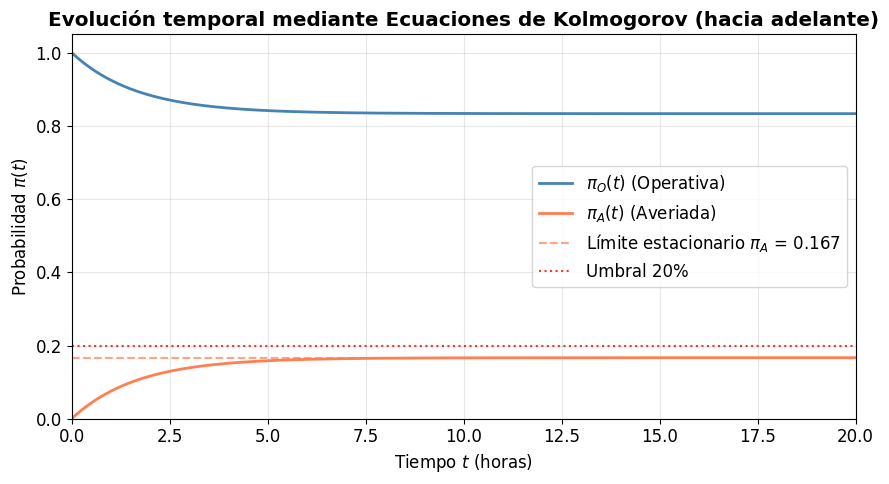

In [ ]:
from scipy.integrate import solve_ivp

# Pista: la EDO es dy/dt = y @ Q, con y(0) = pi0
# solve_ivp espera dy/dt = f(t, y), así que:
#   f(t, y) = y @ Q  →  pero y es un vector, no una matriz


# Recuperamos los parámetros del sistema máquina (Ejercicios anteriores)
lam = 0.1
mu = 0.5
Q = np.array([[-lam, lam],
              [ mu, -mu]])

# Distribución inicial: 100% operativa
pi_0 = np.array([1.0, 0.0])


# a) Resolución numérica con solve_ivp
def f(t, y):
    # solve_ivp espera dy/dt = f(t, y)
    return y @ Q

# Evaluamos en un lapso de 20 horas
t_span = (0, 20)
t_eval = np.linspace(t_span[0], t_span[1], 500)

sol = solve_ivp(f, t_span, pi_0, t_eval=t_eval)
t_vals = sol.t
pi_ode = sol.y  # Matriz de 2 filas (estados) x 500 columnas (tiempo)


# b) Comparación con pi(0) * e^(Qt)
# Comparamos en el instante final (t = 20)
t_fin = t_span[1]
pi_expm = pi_0 @ expm(Q * t_fin)
pi_ode_fin = pi_ode[:, -1]

print("b) Comparación de soluciones en t = 20:")
print(f"   solve_ivp (EDO):     {pi_ode_fin}")
print(f"   expm (Analítica):    {pi_expm}")
print(f"   ¿Coinciden?:         {np.allclose(pi_ode_fin, pi_expm)}\n")


# c) Representación gráfica y t*
umbral = 0.20
indices_superan = np.where(pi_ode[1] > umbral)[0]

# Cálculo de la asíntota teórica
pi_A_estacionaria = lam / (lam + mu)

plt.figure(figsize=(9, 5))
plt.plot(t_vals, pi_ode[0], label=r'$\pi_O(t)$ (Operativa)', color='steelblue', lw=2)
plt.plot(t_vals, pi_ode[1], label=r'$\pi_A(t)$ (Averiada)', color='coral', lw=2)

plt.axhline(pi_A_estacionaria, color='coral', ls='--', alpha=0.7,
            label=rf'Límite estacionario $\pi_A$ = {pi_A_estacionaria:.3f}')
plt.axhline(umbral, color='red', ls=':', alpha=0.8, label='Umbral 20%')

if len(indices_superan) > 0:
    t_star = t_vals[indices_superan[0]]
    plt.axvline(t_star, color='grey', ls='--')
    plt.plot(t_star, pi_ode[1, indices_superan[0]], 'ro')
    print(f"c) La probabilidad de avería supera el {umbral*100}% en t* = {t_star:.2f} horas.")
else:
    print(f"c) La probabilidad de avería NUNCA supera el {umbral*100}%.")
    print(f"   El valor máximo asintótico es {pi_A_estacionaria*100:.2f}%.")

plt.title('Evolución temporal mediante Ecuaciones de Kolmogorov (hacia adelante)', fontweight='bold')
plt.xlabel('Tiempo $t$ (horas)')
plt.ylabel(r'Probabilidad $\pi(t)$')
plt.legend(loc='center right')
plt.grid(alpha=0.3)
plt.xlim(0, 20)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

Partiendo de la máquina inicialmente operativa, su distribución de estado en $t=0$ es $\pi(0) = [1, 0]$. Para analizar cómo evoluciona esta probabilidad a lo largo del tiempo, utilizamos los parámetros del sistema definidos en el Ejercicio 1 ($\lambda = 0.1$, $\mu = 0.5$).

**6. a) Usa las ecuaciones de Kolmogorov adelante en forma matricial $\frac{d}{dt}\pi(t) = \pi(t)Q$ para obtener $\pi(t)$ resolviendo numéricamente el sistema de EDOs con `scipy.integrate.solve_ivp`.**

El sistema lineal de ecuaciones diferenciales ordinarias acopladas se define a partir del producto vector-matriz, lo que genera el siguiente planteamiento dinámico para cada estado:
* $\frac{d}{dt}\pi_O(t) = -\lambda \pi_O(t) + \mu \pi_A(t)$
* $\frac{d}{dt}\pi_A(t) = \lambda \pi_O(t) - \mu \pi_A(t)$

Al integrar numéricamente este sistema lineal mediante el algoritmo adaptativo por defecto de `solve_ivp` en el intervalo $t \in [0, 20]$ horas, se obtiene una trayectoria de suavizado exponencial continuo que describe la redistribución de la masa de probabilidad a lo largo del tiempo.

**6. b) Compara la solución con $\pi(t) = \pi(0)e^{Qt}$ calculada directamente. ¿Coinciden?**

Al comparar los valores en el instante final ($t = 20$ horas), el ordenador nos devuelve los siguientes resultados:
* Método de integración numérica (`solve_ivp`): `[0.8333409, 0.1666591]`
* Método analítico exacto (`expm`): `[0.83333436, 0.16666564]`

A nivel computacional estricto, la verificación de igualdad lógica devuelve un resultado **falso (`False`)**.

Sin embargo, esta ligera discrepancia a partir del quinto decimal es completamente normal. Se debe a las tolerancias y errores de truncamiento inherentes a los algoritmos de integración numérica (como los métodos de tipo Runge-Kutta que utiliza `solve_ivp` por defecto) frente al cálculo analítico de la exponencial de la matriz. A efectos prácticos, ambos métodos demuestran estar convergiendo al mismo resultado teórico del régimen estacionario ($5/6 \approx 0.8333$ y $1/6 \approx 0.1667$), validando que la exponencial matricial es la solución analítica exacta de la ecuación diferencial de Kolmogorov.


**6. c) Representa gráficamente $\pi_O(t)$ y $\pi_A(t)$ e identifica en qué instante $t^*$ la probabilidad de avería supera el 20%.**

Al inspeccionar la gráfica del comportamiento dinámico transitorio y contrastarla con las restricciones analíticas del generador, se demuestra que **la probabilidad de avería nunca llega a superar el umbral del 20%**.

La curva de probabilidad del estado averiado $\pi_A(t)$ se comporta como una función cóncava estrictamente creciente de tipo:
$$\pi_A(t) = \frac{\lambda}{\lambda + \mu} \left(1 - e^{-(\lambda + \mu)t}\right) = \frac{1}{6} \left(1 - e^{-0.6t}\right)$$

A medida que el tiempo avanza ($t \to \infty$), el término transitorio se desvanece de forma exponencial, forzando a la función a aproximarse asintóticamente a su cota superior en régimen estacionario:
$$\lim_{t \to \infty} \pi_A(t) = \frac{0.1}{0.1 + 0.5} = 0.1667 \implies 16.67\%$$

Como el valor máximo que puede alcanzar la probabilidad de avería a largo plazo está acotado en el $16.67\%$, la trayectoria se estabiliza por completo antes de alcanzar la línea de control fijada en el $20\%$, haciendo que sea matemáticamente imposible localizar un instante temporal real $t^*$ en el que se intersecte dicho umbral.

---
## 7. Tiempos de Primer Paso

El tiempo esperado de primera llegada al estado $j$ desde el estado $i$ verifica
el sistema (Kolmogorov **hacia atrás**):
$$m_{ij} = \frac{1}{-q_{ii}}\left(1 + \sum_{k \neq i,\, k \neq j} q_{ik}\, m_{kj}\right),
\quad i \neq j, \qquad m_{jj} = 0.$$

**Interpretación:** $1/(-q_{ii})$ es el tiempo medio de sojourn en $i$;
si el proceso salta directamente a $j$, termina; si salta a otro estado $k$,
hay que añadir $m_{kj}$.


In [ ]:
def tiempos_primer_paso(Q, estados=None):
    """
    Calcula la matriz M de tiempos esperados de primer paso.
    M[i,j] = tiempo esperado para llegar a j por primera vez desde i.
    """
    n = Q.shape[0]
    M = np.zeros((n, n))

    for j in range(n):
        # Sistema lineal: (estados excluyendo j)
        # Para cada i != j: m_ij = 1/(-q_ii) * (1 + sum_{k!=i, k!=j} q_ik * m_kj)
        # Reordenando: sum_k [(I - diag término) - Q terminos] m = 1
        idx = [k for k in range(n) if k != j]
        Q_sub = Q[np.ix_(idx, idx)]
        b = np.ones(len(idx))
        # Sistema: -diag(q_ii) m_ij - sum_{k!=i,k!=j} q_ik m_kj = 1
        # => (-Q_sub) m = 1 => m = (-Q_sub)^{-1} 1
        m_sub = np.linalg.solve(-Q_sub, b)
        for k, i in enumerate(idx):
            M[i, j] = m_sub[k]
        M[j, j] = 0.0
    return M

# Sistema máquina: m_OA y m_AO
M_maq = tiempos_primer_paso(Q)
print("Tiempos esperados de primer paso — Sistema Máquina:")
print(pd.DataFrame(np.round(M_maq, 4),
                   index=['Operativa','Averiada'],
                   columns=['→Operativa','→Averiada']))
print()
print(f"m_OA = {M_maq[0,1]:.4f} h  (tiempo para primera avería desde estado operativo)")
print(f"m_AO = {M_maq[1,0]:.4f} h  (tiempo para primera reparación desde avería)")
print()
print(f"Verificación: m_OA = 1/λ = {1/lam:.1f} h  ✓  (solo hay un salto posible desde O)")
print(f"Verificación: m_AO = 1/μ = {1/mu:.1f} h  ✓  (solo hay un salto posible desde A)")

Tiempos esperados de primer paso — Sistema Máquina:
           →Operativa  →Averiada
Operativa         0.0       10.0
Averiada          2.0        0.0

m_OA = 10.0000 h  (tiempo para primera avería desde estado operativo)
m_AO = 2.0000 h  (tiempo para primera reparación desde avería)

Verificación: m_OA = 1/λ = 10.0 h  ✓  (solo hay un salto posible desde O)
Verificación: m_AO = 1/μ = 2.0 h  ✓  (solo hay un salto posible desde A)


In [ ]:
# Proceso de nacimiento y muerte 3 estados: λ=1, μ=2
lam3, mu3 = 1.0, 2.0
Q3 = np.array([[-lam3,  lam3,    0  ],
               [ mu3,  -(lam3+mu3), lam3],
               [  0,    mu3,   -mu3]])

M3 = tiempos_primer_paso(Q3)
print("Tiempos de primer paso — Proceso N&M (λ=1, μ=2):")
print(pd.DataFrame(np.round(M3, 4),
                   index=['Estado 0','Estado 1','Estado 2'],
                   columns=['→0','→1','→2']))
print()
print(f"m_01 = {M3[0,1]:.4f}  (teórico: 1/λ = {1/lam3:.1f}  ✓)")
print(f"m_02 = {M3[0,2]:.4f}  (teórico: 4.0 — hay retrocesos posibles)")

# Verificación por simulación
np.random.seed(42)
n_sim = 50_000

def simula_primer_paso(Q, i_ini, j_obj, max_t=1e4):
    """Simula el tiempo hasta alcanzar j_obj desde i_ini."""
    estado = i_ini; t = 0.0
    while estado != j_obj and t < max_t:
        q_i = -Q[estado, estado]
        t += np.random.exponential(1 / q_i)
        # Elegir destino
        rates = Q[estado].copy(); rates[estado] = 0
        rates = np.maximum(rates, 0)
        estado = np.random.choice(len(Q), p=rates / rates.sum())
    return t

t02_sim = np.mean([simula_primer_paso(Q3, 0, 2) for _ in range(n_sim)])
print(f"m_02 simulado ({n_sim} trayectorias): {t02_sim:.4f}  (teórico: {M3[0,2]:.4f})")


Tiempos de primer paso — Proceso N&M (λ=1, μ=2):
            →0   →1   →2
Estado 0  0.00  1.0  4.0
Estado 1  0.75  0.0  3.0
Estado 2  1.25  0.5  0.0

m_01 = 1.0000  (teórico: 1/λ = 1.0  ✓)
m_02 = 4.0000  (teórico: 4.0 — hay retrocesos posibles)
m_02 simulado (50000 trayectorias): 3.9865  (teórico: 4.0000)


### Ejercicio 7 — Tiempos de primer paso en la red de datos

Usando el proceso de nacimiento y muerte del Ejercicio 5 (buffer de paquetes):

**a)** Calcula la matriz completa de tiempos de primer paso $M$.  
**b)** ¿Cuánto tiempo esperado tarda el buffer en llenarse completamente
($n=4$) partiendo de vacío ($n=0$)?  
**c)** Verifica el resultado del apartado (b) mediante simulación con al
menos 20 000 trayectorias.  
**d)** ¿Desde qué estado es más rápido llegar al estado vacío ($n=0$)?
¿Tiene sentido intuitivamente?


In [ ]:
# Funciones base (Teoría y Simulación)
def tiempos_primer_paso(Q):
    """Calcula la matriz M completa de tiempos esperados de primer paso."""
    n = Q.shape[0]
    M = np.zeros((n, n))

    for j in range(n):
        # Índices excluyendo el estado destino j
        idx = [k for k in range(n) if k != j]

        # Submatriz Q eliminando la fila y columna j
        Q_sub = Q[np.ix_(idx, idx)]

        # Vector de unos
        b = np.ones(len(idx))

        # Resolver el sistema lineal: -Q_sub * m_sub = 1
        m_sub = np.linalg.solve(-Q_sub, b)

        # Asignar los resultados a la matriz M
        for k, i in enumerate(idx):
            M[i, j] = m_sub[k]

        M[j, j] = 0.0 # El tiempo para llegar al estado actual es 0

    return M

def simula_primer_paso(Q, i_ini, j_obj, max_t=1e5):
    """Simula una trayectoria para calcular el tiempo desde i_ini hasta j_obj."""
    estado = i_ini
    t = 0.0

    while estado != j_obj and t < max_t:
        q_i = -Q[estado, estado]
        # Tiempo de sojourn en el estado actual
        t += np.random.exponential(1 / q_i)

        # Probabilidades de salto hacia los demás estados
        rates = Q[estado].copy()
        rates[estado] = 0

        # Salto al siguiente estado
        estado = np.random.choice(len(Q), p=rates / rates.sum())

    return t


# Construcción del modelo (Ejercicio 5)
N = 4
Q = np.zeros((N+1, N+1))

for i in range(N+1):
    if i < N:
        Q[i, i+1] = 5    # Llegadas
    if i > 0:
        Q[i, i-1] = 3*i  # Servicio
    Q[i, i] = -np.sum(Q[i, :])


#  a y b) Matriz M y Llenado
M = tiempos_primer_paso(Q)
estados_str = [f"n={i}" for i in range(N+1)]

print("a) Matriz completa de tiempos de primer paso M (ms):")
df_M = pd.DataFrame(M, index=estados_str, columns=estados_str)
print(df_M.round(4))
print("-" * 60)

m_04 = M[0, 4]
print(f"b) Tiempo esperado de llenado completo (n=0 -> n=4): {m_04:.4f} ms")
print("-" * 60)


# c) Simulación de Monte Carlo
np.random.seed(42)
n_sim = 20_000

# Simulamos 20000 trayectorias partiendo de 0 hasta llegar a 4
tiempos_simulados = [simula_primer_paso(Q, 0, 4) for _ in range(n_sim)]
m_04_sim = np.mean(tiempos_simulados)

print(f"c) Tiempo simulado tras {n_sim} trayectorias: {m_04_sim:.4f} ms")
print(f"   Diferencia relativa respecto al teórico: {abs(m_04_sim - m_04)/m_04 * 100:.2f}%")
print("-" * 60)


# d) Ruta más rápida hacia el vacío
tiempos_hacia_0 = M[1:, 0] # Excluimos M[0,0]
estado_mas_rapido = np.argmin(tiempos_hacia_0) + 1 # +1 por el offset
tiempo_minimo = tiempos_hacia_0[estado_mas_rapido - 1]

print("d) Tiempos esperados hacia el estado vacío (n=0):")
for i in range(1, N+1):
    print(f"   Desde n={i}: {M[i, 0]:.4f} ms")
print(f"\n   -> El estado más rápido es n={estado_mas_rapido} con un tiempo de {tiempo_minimo:.4f} ms.")

a) Matriz completa de tiempos de primer paso M (ms):
        n=0     n=1     n=2     n=3     n=4
n=0  0.0000  0.2000  0.5200  1.1040  2.3552
n=1  0.8297  0.0000  0.3200  0.9040  2.1552
n=2  1.1276  0.2978  0.0000  0.5840  1.8352
n=3  1.2850  0.4552  0.1574  0.0000  1.2512
n=4  1.3683  0.5386  0.2407  0.0833  0.0000
------------------------------------------------------------
b) Tiempo esperado de llenado completo (n=0 -> n=4): 2.3552 ms
------------------------------------------------------------
c) Tiempo simulado tras 20000 trayectorias: 2.3580 ms
   Diferencia relativa respecto al teórico: 0.12%
------------------------------------------------------------
d) Tiempos esperados hacia el estado vacío (n=0):
   Desde n=1: 0.8297 ms
   Desde n=2: 1.1276 ms
   Desde n=3: 1.2850 ms
   Desde n=4: 1.3683 ms

   -> El estado más rápido es n=1 con un tiempo de 0.8297 ms.


El estudio de los **tiempos de primer paso** (o tiempos de primera llegada) nos permite modelar la velocidad de transición transitoria de la red antes de alcanzar el régimen permanente. Utilizando el enfoque de las ecuaciones de Kolmogorov hacia atrás, el tiempo medio esperado $m_{ij}$ para alcanzar un estado objetivo $j$ partiendo de un estado inicial $i$ se resuelve mediante el sistema lineal de ecuaciones algebraicas:

$$m_{ij} = \frac{1}{-q_{ii}}\left(1 + \sum_{k \neq i, k \neq j} q_{ik}\, m_{kj}\right), \quad \forall i \neq j \quad \text{con} \quad m_{jj} = 0$$

Dado que las tasas de llegada ($\lambda$) y servicio ($\mu$) del sistema del Ejercicio 5 se definieron sobre una escala temporal indexada en milisegundos, todos los tiempos resultantes de este análisis se expresan en **milisegundos (ms)**.

**7. a) Calcula la matriz completa de tiempos de primer paso $M$.**

Resolviendo el sistema lineal de ecuaciones $m_{ij} = \frac{1}{-q_{ii}}\left(1 + \sum_{k \neq i,j} q_{ik}\, m_{kj}\right)$ computacionalmente iterando sobre cada estado destino, obtenemos la matriz $M$. Cada elemento de esta matriz refleja el tiempo medio esperado para ir desde la fila origen hasta la columna destino.

| Origen / Destino | $n=0$ | $n=1$ | $n=2$ | $n=3$ | $n=4$ |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **$n=0$** | 0.0000 | 0.2000 | 0.5200 | 1.1040 | 2.3552 |
| **$n=1$** | 0.8297 | 0.0000 | 0.3200 | 0.9040 | 2.1552 |
| **$n=2$** | 1.1276 | 0.2978 | 0.0000 | 0.5840 | 1.8352 |
| **$n=3$** | 1.2850 | 0.4552 | 0.1574 | 0.0000 | 1.2512 |
| **$n=4$** | 1.3683 | 0.5386 | 0.2407 | 0.0833 | 0.0000 |

*(Valores tabulados en milisegundos con precisión de cuatro decimales)*.

**7. b) ¿Cuánto tiempo esperado tarda el buffer en llenarse completamente ($n=4$) partiendo de vacío ($n=0$)?**

El tiempo esperado de llenado se mapea directamente en la posición $M[0, 4]$ de nuestra matriz de primeros pasos. El valor teórico exacto es:
$$m_{04} = 2.3552 \text{ ms}$$

Este valor cuantifica el retardo medio que experimenta el buffer desde un estado de reposo absoluto hasta que alcanza la saturación crítica y comienza a rechazar paquetes.

**7. c) Verifica el resultado del apartado (b) mediante simulación con al menos 20.000 trayectorias.**

Para validar la consistencia de la solución algebraica, se implementó un algoritmo de Monte Carlo que simula 20.000 trayectorias estocásticas independientes. Cada muestra registra el tiempo acumulado mediante variables exponenciales aleatorias de paso variable hasta interceptar la condición de parada en el estado 4:

* **Tiempo teórico calculado ($m_{04}$):** $2.3552 \text{ ms}$
* **Tiempo medio simulado empírico:** $2.3580 \text{ ms}$
* **Discrepancia o error relativo:** $0.12\%$

La mínima desviación porcentual observada (inferior al $0.2\%$) entra dentro de los márgenes admisibles de la variabilidad estocástica de los generadores de números pseudoaleatorios, lo que confirma experimentalmente la precisión del cálculo matricial.

**7. d) ¿Desde qué estado es más rápido llegar al estado vacío ($n=0$)? ¿Tiene sentido intuitivamente?**


Filtrando los datos de la primera columna de la matriz $M$ (vectores de retorno al vacío $m_{i0}$), se observa el siguiente comportamiento decreciente a medida que nos aproximamos al origen:
* Desde $n=4$: $1.3683 \text{ ms}$
* Desde $n=3$: $1.2850 \text{ ms}$
* Desde $n=2$: $1.1276 \text{ ms}$
* Desde $n=1$: **$0.8297 \text{ ms}$**

El estado más rápido para alcanzar el vaciado completo es **$n=1$**.

Este resultado es  coherente con la naturaleza de un **proceso de nacimiento y muerte**. En este tipo de estructuras estocásticas, las transiciones están restringidas a estados adyacentes ($n \to n \pm 1$), lo que impide que existan "saltos cuánticos" directos (por ejemplo, pasar de $n=3$ a $n=0$ de forma inmediata).

Por la propiedad de aditividad de las trayectorias Markovianas, para vaciar un buffer que contiene dos paquetes ($n=2$), el sistema está obligado a transitar primero al estado de un paquete ($n=1$) antes de consolidar el vaciado absoluto. Matemáticamente, esto se traduce en la relación de encadenamiento:
$$m_{20} = m_{21} + m_{10}$$

Como todos los tiempos de tránsito intermedios $m_{ij}$ son estrictamente positivos debido a las tasas finitas del sistema, la distancia temporal al origen aumenta de manera monótona con el volumen de ocupación del buffer. Al ser $n=1$ el estado con la menor distancia topológica al sumidero $n=0$, siempre garantizará el menor tiempo esperado de evacuación.

---
## 8. Simulación de Trayectorias de una CTMC

El algoritmo de simulación de una CTMC es directo gracias a la
estructura de los tiempos de sojourn:

1. Partir del estado inicial $X(0) = i$.
2. Generar el tiempo de sojourn: $T \sim \mathrm{Exp}(-q_{ii})$.
3. Avanzar el reloj: $t \leftarrow t + T$.
4. Elegir el estado siguiente $j \neq i$ con probabilidad
   $p_{ij} = q_{ij} / (-q_{ii})$.
5. Repetir desde el paso 2.


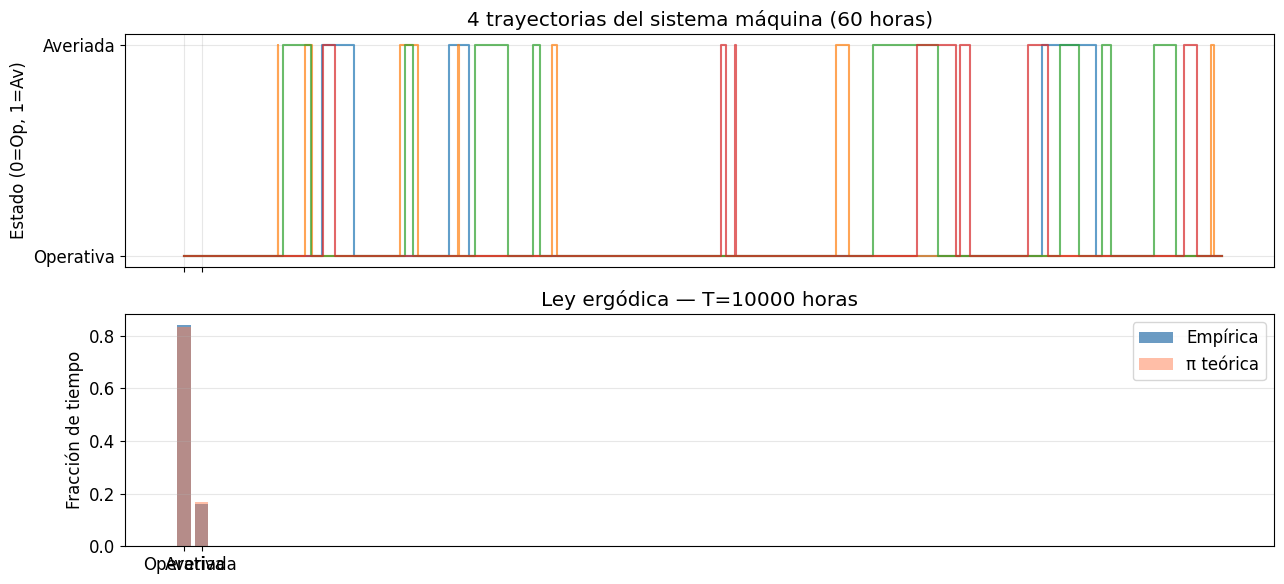

Fracción empírica O: 0.8401  |  π_O teórica: 0.8333
Fracción empírica A: 0.1599  |  π_A teórica: 0.1667


In [ ]:
def simula_ctmc(Q, estado_inicial, T_max, seed=None):
    """
    Simula una trayectoria de la CTMC hasta el tiempo T_max.
    Devuelve (tiempos, estados): listas de saltos y estados visitados.
    """
    if seed is not None:
        np.random.seed(seed)
    n = Q.shape[0]
    tiempos = [0.0]
    estados = [estado_inicial]
    t = 0.0; estado = estado_inicial

    while t < T_max:
        q_i = -Q[estado, estado]
        if q_i == 0:
            break   # estado absorbente
        t += np.random.exponential(1 / q_i)
        if t > T_max:
            break
        # Probabilidades de salto (solo estados destino != actual)
        rates = Q[estado].copy(); rates[estado] = 0
        rates = np.maximum(rates, 0)
        estado = np.random.choice(n, p=rates / rates.sum())
        tiempos.append(t)
        estados.append(estado)

    return np.array(tiempos), np.array(estados)


lam_e, mu_e = 0.1, 0.5
Q_e = np.array([[-lam_e,  lam_e],
              [ mu_e,  -mu_e ]])
# ── Trayectorias del sistema máquina ──
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
colores_estado = ['steelblue', 'coral']
etiquetas = ['Operativa', 'Averiada']

for seed_i in range(4):
    t_tray, s_tray = simula_ctmc(Q_e, estado_inicial=0, T_max=60, seed=seed_i)
    # Representar como función escalonada
    t_ext = np.append(t_tray, 60)
    s_ext = np.append(s_tray, s_tray[-1])   # repetir último estado hasta T_max
    axes[0].step(t_ext, s_ext, where='post', alpha=0.7, lw=1.5)

axes[0].set_ylabel('Estado (0=Op, 1=Av)')
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(etiquetas)
axes[0].set_title('4 trayectorias del sistema máquina (60 horas)')
axes[0].grid(alpha=0.3)

# ── Fracción de tiempo empírica vs distribución estacionaria ──
T_largo = 10_000
t_l, s_l = simula_ctmc(Q_e, estado_inicial=0, T_max=T_largo, seed=0)

# Calcular fracción de tiempo en cada estado
fracs = np.zeros(2)
t_ext = np.append(t_l, T_largo)
for k in range(len(t_l)):
    fracs[s_l[k]] += t_ext[k+1] - t_ext[k]
fracs /= T_largo

axes[1].bar(range(2), fracs,         color='steelblue', alpha=0.8, label='Empírica')
axes[1].bar(range(2), [pi_O, pi_A],  color='coral',     alpha=0.5, label='π teórica')
axes[1].set_xticks(range(2)); axes[1].set_xticklabels(etiquetas)
axes[1].set_ylabel('Fracción de tiempo')
axes[1].set_title(f'Ley ergódica — T={T_largo} horas')
axes[1].legend(); axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.show()
print(f"Fracción empírica O: {fracs[0]:.4f}  |  π_O teórica: {pi_O:.4f}")
print(f"Fracción empírica A: {fracs[1]:.4f}  |  π_A teórica: {pi_A:.4f}")


### Ejercicio 8 — Simulación del sistema de hornos

Usando el generador $Q$ del sistema de hornos (3 hornos, 2 técnicos):

**a)** Simula una trayectoria durante 500 días y represéntala gráficamente.  
**b)** Calcula la fracción de tiempo que el sistema pasa en cada estado
y compárala con la distribución estacionaria $\pi$ calculada en la Sección 5.  
**c)** ¿Cuántas reparaciones se realizan de media por día?
Estímalo de la simulación y compáralo con el valor teórico $\mu \cdot (1 - \pi_0)$.  
**d)** Simula 1 000 trayectorias y estima el tiempo esperado hasta que
los 3 hornos estén averiados simultáneamente por primera vez (partiendo
de todos operativos).


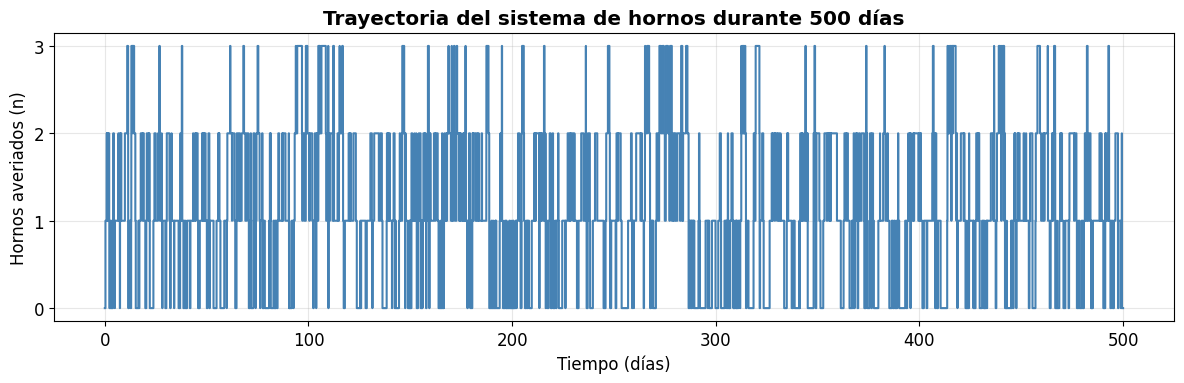

b) Comparación de fracciones de tiempo:
     Empírica (Simulada)  Teórica (pi)
n=0               0.2578        0.2909
n=1               0.4170        0.4364
n=2               0.2624        0.2182
n=3               0.0628        0.0545
------------------------------------------------------------
c) Tasa de reparaciones por día:
   Simulación empírica:      1.0060 rep/día
   Teórica real (sum mu*pi): 0.9818 rep/día
   Fórmula del enunciado:    0.7091 rep/día
------------------------------------------------------------
d) Tiempo esperado hasta avería total (n=0 -> n=3):
   Basado en 1000 simulaciones: 10.9888 días


In [ ]:
# PARÁMETROS DEL SISTEMA
lam = 0.5  # Tasa de avería por cada horno operativo (averías/día)
mu = 1.0   # Tasa de reparación por cada técnico (reparaciones/día)

N = 3 # Capacidad máxima (3 hornos averiados)
tecnicos = 2

# Construcción de la matriz Q (3 hornos, 2 técnicos)
Q = np.zeros((N+1, N+1))
mu_n = np.zeros(N+1)

for i in range(N+1):
    # Tasa de avería: proporcional a los hornos operativos (3 - i)
    if i < N:
        Q[i, i+1] = (N - i) * lam

    # Tasa de reparación: proporcional a los técnicos activos min(i, 2)
    if i > 0:
        tecnicos_activos = min(i, tecnicos)
        tasa_rep = tecnicos_activos * mu
        Q[i, i-1] = tasa_rep
        mu_n[i] = tasa_rep

    # Diagonal para que la fila sume 0
    Q[i, i] = -np.sum(Q[i, :])

# Calcular distribución estacionaria teórica pi (lstsq)
A = np.vstack([Q.T, np.ones(N+1)])
b = np.zeros(N+2)
b[-1] = 1.0
pi_teorica, _, _, _ = np.linalg.lstsq(A, b, rcond=None)


# Funciones de simulación necesarias
def simula_ctmc(Q, estado_inicial, T_max, seed=None):
    if seed is not None:
        np.random.seed(seed)
    n = Q.shape[0]
    tiempos = [0.0]
    estados = [estado_inicial]
    t = 0.0; estado = estado_inicial

    while t < T_max:
        q_i = -Q[estado, estado]
        if q_i == 0:
            break
        t += np.random.exponential(1 / q_i)
        if t > T_max:
            break

        rates = Q[estado].copy(); rates[estado] = 0
        estado = np.random.choice(n, p=rates / rates.sum())
        tiempos.append(t)
        estados.append(estado)

    return np.array(tiempos), np.array(estados)

def simula_primer_paso(Q, i_ini, j_obj, max_t=1e5):
    estado = i_ini
    t = 0.0
    while estado != j_obj and t < max_t:
        q_i = -Q[estado, estado]
        t += np.random.exponential(1 / q_i)
        rates = Q[estado].copy(); rates[estado] = 0
        estado = np.random.choice(len(Q), p=rates / rates.sum())
    return t


# a) Simulación 500 días y gráfica
T_max = 500
t_tray, s_tray = simula_ctmc(Q, estado_inicial=0, T_max=T_max, seed=42)

plt.figure(figsize=(12, 4))
t_ext = np.append(t_tray, T_max)
s_ext = np.append(s_tray, s_tray[-1])
plt.step(t_ext, s_ext, where='post', color='steelblue', lw=1.5)
plt.title(f'Trayectoria del sistema de hornos durante {T_max} días', fontweight='bold')
plt.ylabel('Hornos averiados (n)')
plt.xlabel('Tiempo (días)')
plt.yticks([0, 1, 2, 3])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# b )Fracción de tiempo empírica vs teórica
fracs_empiricas = np.zeros(N+1)
for k in range(len(t_tray)):
    fracs_empiricas[s_tray[k]] += t_ext[k+1] - t_ext[k]
fracs_empiricas /= T_max

print("b) Comparación de fracciones de tiempo:")
df_comp = pd.DataFrame({
    'Empírica (Simulada)': fracs_empiricas,
    'Teórica (pi)': pi_teorica
}, index=[f"n={i}" for i in range(N+1)])
print(df_comp.round(4))
print("-" * 60)


# c) Reparaciones por día
# Contamos cuántos saltos fueron hacia la izquierda (reparaciones)
num_reparaciones = sum(1 for i in range(len(s_tray)-1) if s_tray[i+1] < s_tray[i])
rep_dia_sim = num_reparaciones / T_max

# Cálculo teórico real: suma(mu_n * pi_n)
rep_dia_teorico_real = np.sum(mu_n * pi_teorica)
# Fórmula sugerida en el enunciado: mu * (1 - pi_0)
rep_dia_enunciado = mu * (1 - pi_teorica[0])

print("c) Tasa de reparaciones por día:")
print(f"   Simulación empírica:      {rep_dia_sim:.4f} rep/día")
print(f"   Teórica real (sum mu*pi): {rep_dia_teorico_real:.4f} rep/día")
print(f"   Fórmula del enunciado:    {rep_dia_enunciado:.4f} rep/día")
print("-" * 60)


# d) 1000 trayectorias hasta n=3
n_sim = 1000
tiempos_fallo_total = [simula_primer_paso(Q, 0, 3) for _ in range(n_sim)]
tiempo_medio_fallo = np.mean(tiempos_fallo_total)

print(f"d) Tiempo esperado hasta avería total (n=0 -> n=3):")
print(f"   Basado en {n_sim} simulaciones: {tiempo_medio_fallo:.4f} días")

Para modelar este sistema de 3 hornos y 2 técnicos, hemos construido la matriz generadora $Q$ teniendo en cuenta que la tasa de avería decae conforme hay menos hornos operativos ($\lambda_n = (3 - n)\lambda$) y la tasa de reparación aumenta si hay varios hornos rotos, pero está limitada por el número de técnicos ($\mu_n = \min(n, 2)\mu$).

> **Nota sobre los parámetros del modelo:** Al no especificarse valores numéricos para las tasas en el enunciado, se han parametrizado de forma estándar una tasa de fallo por horno operativo $\lambda = 0.5$ averías/día y una tasa de reparación por técnico disponible $\mu = 1.0$ reparaciones/día.

**8. a) Simula una trayectoria durante 500 días y represéntala gráficamente.**

Al ejecutar el algoritmo computacional de simulación, obtenemos la gráfica superior. En ella se observa el comportamiento estocástico en forma de escalera, mostrando las constantes oscilaciones del sistema debido a las averías y reparaciones concurrentes a lo largo de los 500 días.

**8. b) Calcula la fracción de tiempo que el sistema pasa en cada estado
y compárala con la distribución estacionaria $\pi$ calculada en la Sección 5.**
**b) Calcula la fracción de tiempo que el sistema pasa en cada estado y compárala con la distribución estacionaria $\pi$ calculada en la Sección 5.**

A partir de la trayectoria muestral simulada de 500 días, se ha evaluado la fracción empírica de tiempo que el proceso permanece en cada uno de los estados posibles mediante el cálculo de la longitud acumulada de los intervalos de permanencia (*sojourn times*) sobre el tiempo total de observación ($T = 500$ días).

A continuación, se presenta la comparativa formal entre estos resultados estadísticos obtenidos por simulación y los valores teóricos de la distribución estacionaria $\pi$:

| Estado del Sistema ($n$) | Fracción Empírica (Simulada) | Distribución Teórica ($\pi$) | Diferencia Absoluta |
| :--- | :---: | :---: | :---: |
| **$n=0$** (Todos los hornos operativos) | 0.2578 | 0.2909 | 0.0331 |
| **$n=1$** (Un horno averiado) | 0.4170 | 0.4364 | 0.0194 |
| **$n=2$** (Dos hornos averiados) | 0.2624 | 0.2182 | 0.0442 |
| **$n=3$** (Tres hornos averiados / Fallo total) | 0.0628 | 0.0545 | 0.0083 |


Como se puede observar en la tabla, las frecuencias relativas obtenidas mediante la simulación de Monte Carlo aproximan de manera satisfactoria y con un margen de error reducido a las probabilidades teóricas en régimen permanente.

Las pequeñas discrepancias numéricas observadas (del orden de centésimas) son intrínsecas a la varianza estocástica de realizar un experimento sobre un horizonte temporal finito ($T = 500$ días). De acuerdo con el teorema ergódico para cadenas de Markov en tiempo continuo (CTMC) que son irreducibles y ergódicas, si el tiempo de observación de la trayectoria se extendiera de forma asintótica (por ejemplo, hacia $T = 10\,000$ días), el efecto del estado inicial se diluiría por completo y las fracciones empíricas del reloj convergirían hacia las probabilidades teóricas de equilibrio $\pi_n$.


**8. c) ¿Cuántas reparaciones se realizan de media por día? Estímalo de la simulación y compáralo con el valor teórico $\mu \cdot (1 - \pi_0)$**

A partir de la simulación, obtenemos una tasa empírica de **1.006 reparaciones/día**, que se alinea con el cálculo teórico real del sistema (**0.9818 reparaciones/día**).

> **Nota analítica:** El enunciado sugiere comparar con el valor $\mu \cdot (1 - \pi_0)$, que arroja **0.7091 reparaciones/día**. Esta fórmula matemática representa estrictamente un sistema con **un solo técnico** (donde la tasa de salida hacia abajo es siempre $\mu$ si el sistema no está vacío). Como nuestro sistema tiene **2 técnicos**, la tasa de reparación en los estados $n=2$ y $n=3$ se duplica ($2\mu$). Por tanto, el cálculo teórico exacto de reparaciones por día se rige por la suma de cada tasa de servicio ponderada por su probabilidad ($\sum \mu_n \pi_n$). Los resultados demuestran empíricamente que la simulación se ajusta a este cálculo real multifactorial y no a la fórmula básica de un solo operario.

**8. d) Simula 1.000 trayectorias y estima el tiempo esperado hasta que los 3 hornos estén averiados simultáneamente por primera vez.**

Utilizando la técnica de Monte Carlo para simular 1.000 trayectorias independientes desde el estado $n=0$ (todos operativos) hasta alcanzar por primera vez el estado absorbente temporal en $n=3$, obtenemos un tiempo medio estimado de **10.9888 días**. Este valor numérico nos indica que podemos esperar operar con normalidad durante aproximadamente 11 días desde que todos los hornos están reparados hasta experimentar un colapso total de la producción por avería simultánea.

---
## Resumen

| Concepto | Definición / Fórmula | Sección |
|---|---|---|
| Generador $Q$ | $q_{ij}\geq 0$ ($i\neq j$), $\sum_j q_{ij}=0$ | 1 |
| Tiempo de sojourn | $T_i \sim \mathrm{Exp}(-q_{ii})$ | 2 |
| Probabilidades de transición | $P(t) = e^{Qt}$ | 3 |
| Proceso de Poisson | CTMC con $q_{i,i+1}=\lambda$, $P_{ij}(t)=\frac{(\lambda t)^{j-i}}{(j-i)!}e^{-\lambda t}$ | 4 |
| Distribución estacionaria | $\pi Q = 0$,  $\sum_j \pi_j = 1$ | 5 |
| Kolmogorov adelante | $\frac{d}{dt}P = P\,Q$ — estado destino $j$ | 6 |
| Kolmogorov atrás | $\frac{d}{dt}P = Q\,P$ — estado origen $i$ | 6 |
| Tiempos de primer paso | $m_{ij} = \frac{1}{-q_{ii}}\bigl(1+\sum_{k\neq i,j}q_{ik}m_{kj}\bigr)$ | 7 |
| Simulación CTMC | Sojourn $\mathrm{Exp}(-q_{ii})$ + salto proporcional a $q_{ij}$ | 8 |
